In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
import random
import scipy.linalg

In [2]:
#import pymanopt
#import pymanopt.manifolds
#import pymanopt.optimizers
#import autograd.numpy as anp

import torch
import mctorch.nn as mnn
import mctorch.optim as moptim

In [3]:
poly = PolynomialFeatures(1)

In [4]:
X = pd.read_csv("TestMat.csv", header=None)
X = X.to_numpy()
X.shape

(65536, 10)

In [5]:
'''# define the S1 dataset at z=1.

def getPhi(): # azimuthal angle
    s1 = random.random()
    s2 = s1*2*np.pi
    return s2


def getX(phi):
    x = np.cos(phi)
    return x


def getY(phi):
    y = np.sin(phi)
    return y


def getZ(phi):
    z = 1.0
    return z


list = []
size = 2**12 # feel free to change this
# Create the dataset.
for i in range(size):
    phi = getPhi()
    x = getX(phi)
    y = getY(phi)
    z = getZ(phi)
    list.append([x,y,z])
    
X = np.array(list)
Xt = X.transpose()'''

'# define the S1 dataset at z=1.\n\ndef getPhi(): # azimuthal angle\n    s1 = random.random()\n    s2 = s1*2*np.pi\n    return s2\n\n\ndef getX(phi):\n    x = np.cos(phi)\n    return x\n\n\ndef getY(phi):\n    y = np.sin(phi)\n    return y\n\n\ndef getZ(phi):\n    z = 1.0\n    return z\n\n\nlist = []\nsize = 2**12 # feel free to change this\n# Create the dataset.\nfor i in range(size):\n    phi = getPhi()\n    x = getX(phi)\n    y = getY(phi)\n    z = getZ(phi)\n    list.append([x,y,z])\n    \nX = np.array(list)\nXt = X.transpose()'

In [6]:
B = poly.fit_transform(X)
B.shape

(65536, 11)

In [7]:
#newB = np.hstack((X, X**2))

In [8]:
#newB.shape

In [9]:
#const = np.array([[1] for i in range(X.shape[0])])

In [10]:
#newB2 = np.hstack((const,X,X**2))

In [11]:
#newB2.shape

In [12]:
poly.get_feature_names_out()

array(['1', 'x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9'],
      dtype=object)

In [13]:
poly.n_features_in_

10

In [48]:
def tryDim(B, d, n_epochs=5000, criterion=torch.nn.MSELoss(), optimizer=moptim.rSGD, lr=1e-2):
    manifold_param = mnn.Parameter(manifold=mnn.Stiefel(B.shape[1],d))
    Btensor = torch.tensor(B).float()
    
    def model(mat):
        term1 = torch.matmul(Btensor, mat)
        return term1
    
    y = torch.zeros((B.shape[0],d))
    
    optimizer = optimizer(params = [manifold_param], lr=lr)
    for epoch in range(n_epochs):
        y_pred = model(manifold_param)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
    return loss.item(), manifold_param

In [15]:
t1 = tryDim(B,1)

/home/ben/anaconda3/lib/python3.8/site-packages/mctorch/nn/manifolds/stiefel.py:50: UserWarning: torch.qr is deprecated in favor of torch.linalg.qr and will be removed in a future PyTorch release.
The boolean parameter 'some' has been replaced with a string parameter 'mode'.
Q, R = torch.qr(A, some)
should be replaced with
Q, R = torch.linalg.qr(A, 'reduced' if some else 'complete') (Triggered internally at  /opt/conda/conda-bld/pytorch_1634272128894/work/aten/src/ATen/native/BatchLinearAlgebra.cpp:1937.)
  q, r = torch.qr(X)


In [16]:
t2 = tryDim(B,2)

In [17]:
t3 = tryDim(B,3)

In [18]:
t4 = tryDim(B,4)

In [19]:
t5 = tryDim(B,5)

In [20]:
t6 = tryDim(B,6)

In [21]:
t7 = tryDim(B,7)

In [22]:
costs = [t1[0], t2[0], t3[0], t4[0], t5[0], t6[0], t7[0]]
costs

[4.098586433350787e-13,
 2.4907799347356763e-12,
 2.0971474556930048e-11,
 5.7879062653753977e-11,
 8.5739262911666e-11,
 0.22153092920780182,
 0.3812144696712494]

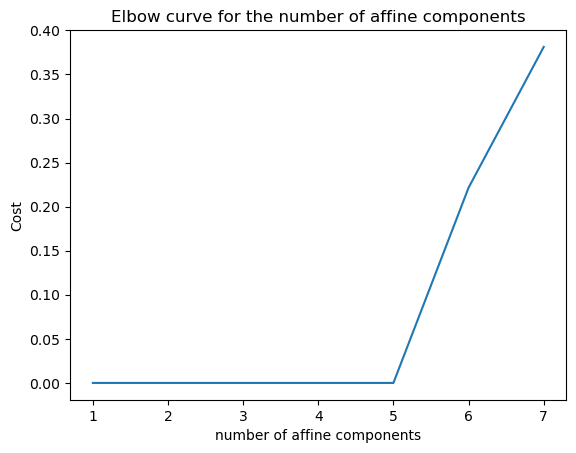

In [25]:
plt.plot([i+1 for i in range(7)], [t1[0], t2[0], t3[0], t4[0], t5[0], t6[0], t7[0]])
plt.xlabel("number of affine components")
plt.ylabel("Cost")
plt.title("Elbow curve for the number of affine components")
plt.show()

In [27]:
t5

(8.5739262911666e-11,
 Parameter containing:
 tensor([[ 1.0297e-01,  8.9775e-02, -3.7226e-01, -8.2168e-01,  3.3473e-01],
         [ 1.0431e-02, -8.6370e-01, -8.8322e-02, -1.3935e-01, -2.1185e-01],
         [-1.1738e-08,  4.0056e-08, -1.1081e-05,  3.8636e-06, -4.1116e-06],
         [-8.5116e-09,  4.5246e-09,  1.1904e-08, -1.1199e-05,  9.6660e-07],
         [ 3.1646e-01,  2.2424e-01, -4.0102e-01,  9.6745e-02, -3.6598e-01],
         [-1.6345e-01,  3.1973e-01,  2.4467e-01,  2.1300e-02,  2.8891e-01],
         [-2.7293e-07,  1.6970e-06, -4.0337e-07,  6.5112e-07, -1.5857e-07],
         [ 2.9534e-02, -6.9442e-02, -2.0686e-02,  3.1182e-01,  8.8084e-02],
         [-8.4411e-01,  5.4837e-02, -5.1447e-01,  8.8847e-02, -1.0908e-01],
         [ 3.1646e-01,  2.2424e-01, -4.0101e-01,  9.6746e-02, -3.6598e-01],
         [-2.2111e-01,  1.8799e-01,  4.5500e-01, -4.2559e-01, -6.8707e-01]],
        requires_grad=True))

In [26]:
t5[1][1].detach().numpy()

array([ 0.01043064, -0.8636981 , -0.0883217 , -0.13934612, -0.21184658],
      dtype=float32)

In [28]:
A1 = np.array([t5[1][i].detach().numpy() for i in range(1,t5[1].shape[0])]).transpose()

In [29]:
A1

array([[ 1.0430644e-02, -1.1738025e-08, -8.5115914e-09,  3.1645668e-01,
        -1.6344517e-01, -2.7293282e-07,  2.9534381e-02, -8.4410870e-01,
         3.1645921e-01, -2.2111104e-01],
       [-8.6369812e-01,  4.0055877e-08,  4.5246438e-09,  2.2424461e-01,
         3.1972980e-01,  1.6970106e-06, -6.9441639e-02,  5.4836504e-02,
         2.2424321e-01,  1.8798679e-01],
       [-8.8321701e-02, -1.1080637e-05,  1.1904314e-08, -4.0101597e-01,
         2.4466680e-01, -4.0336795e-07, -2.0685600e-02, -5.1447099e-01,
        -4.0101308e-01,  4.5500246e-01],
       [-1.3934612e-01,  3.8636313e-06, -1.1198964e-05,  9.6745498e-02,
         2.1300195e-02,  6.5112221e-07,  3.1181693e-01,  8.8847324e-02,
         9.6746027e-02, -4.2558959e-01],
       [-2.1184658e-01, -4.1115991e-06,  9.6660483e-07, -3.6598271e-01,
         2.8891361e-01, -1.5857097e-07,  8.8084094e-02, -1.0908343e-01,
        -3.6598036e-01, -6.8706733e-01]], dtype=float32)

In [30]:
A1.shape

(5, 10)

In [31]:
A2 = scipy.linalg.null_space(A1) #gives an O.N. basis.
A2

array([[ 2.0372943e-06,  3.0713993e-01,  1.9325593e-01,  8.2196400e-02,
         2.0828025e-01],
       [-2.1214391e-06, -4.4740754e-01,  7.4700570e-01, -4.6788877e-01,
         1.5129133e-01],
       [ 5.9119719e-07,  1.4913175e-01,  4.7064179e-01,  3.5161287e-01,
        -7.9537690e-01],
       [ 1.3864651e-07,  5.1325840e-01,  9.8369531e-03, -5.1580405e-01,
        -1.2596792e-01],
       [ 6.3788099e-07,  6.1427444e-01,  3.8651597e-01,  1.6439030e-01,
         4.1655746e-01],
       [ 1.0000000e+00, -2.2796517e-06,  8.0157213e-07, -9.5555049e-07,
         3.6767045e-07],
       [-1.3262400e-06,  9.8254450e-06,  1.8050252e-05,  1.4570592e-05,
        -3.3476645e-05],
       [-6.0610199e-07,  6.3256857e-07, -4.6579607e-06,  5.3315389e-06,
        -1.6298991e-06],
       [-7.4531056e-07, -2.0611644e-01,  1.8341109e-01,  5.9800851e-01,
         3.3424208e-01],
       [-3.4136585e-07, -9.5865141e-07,  5.2102655e-06,  6.8702991e-07,
        -3.6844833e-06]], dtype=float32)

In [32]:
NewX = X@A2

In [33]:
NewX.shape

(65536, 5)

In [34]:
#plt.scatter(NewX.transpose()[0], NewX.transpose()[1])

In [35]:
poly2 = PolynomialFeatures(2)

In [36]:
B2 = poly2.fit_transform(NewX)

In [37]:
B2.shape

(65536, 21)

In [38]:
poly2.get_feature_names_out()

array(['1', 'x0', 'x1', 'x2', 'x3', 'x4', 'x0^2', 'x0 x1', 'x0 x2',
       'x0 x3', 'x0 x4', 'x1^2', 'x1 x2', 'x1 x3', 'x1 x4', 'x2^2',
       'x2 x3', 'x2 x4', 'x3^2', 'x3 x4', 'x4^2'], dtype=object)

In [49]:
t1a = tryDim(B2,1,criterion=torch.nn.L1Loss(), optimizer=moptim.rAdagrad, lr=0.01)

In [51]:
t2a = tryDim(B2,2,criterion=torch.nn.L1Loss(), optimizer=moptim.rAdagrad, lr=0.01)

In [52]:
t3a = tryDim(B2,3,criterion=torch.nn.L1Loss(), optimizer=moptim.rAdagrad, lr=0.01)

In [53]:
t4a = tryDim(B2,4,criterion=torch.nn.L1Loss(), optimizer=moptim.rAdagrad, lr=0.01)

In [54]:
t5a = tryDim(B2,5,criterion=torch.nn.L1Loss(), optimizer=moptim.rAdagrad, lr=0.01)

In [55]:
t6a = tryDim(B2,6,criterion=torch.nn.L1Loss(), optimizer=moptim.rAdagrad, lr=0.01)

In [77]:
costsA = [0,t1a[0], t2a[0], t3a[0], t4a[0], t5a[0], t6a[0]]
costsA

[0,
 0.0018964994233101606,
 0.15836209058761597,
 0.22235338389873505,
 0.2655358910560608,
 0.30455511808395386,
 0.38616111874580383]

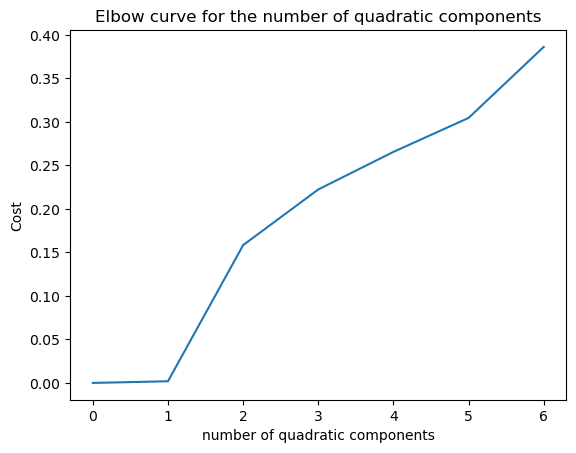

In [78]:
plt.plot([i for i in range(7)], costsA)
plt.xlabel("number of quadratic components")
plt.ylabel("Cost")
plt.title("Elbow curve for the number of quadratic components")
plt.show()

In [57]:
t1a[1]

Parameter containing:
tensor([[ 1.9503e-03],
        [-5.0315e-01],
        [-1.5430e-01],
        [-9.7075e-02],
        [-4.1295e-02],
        [-1.0450e-01],
        [ 2.3755e-04],
        [ 4.7610e-04],
        [ 3.3471e-04],
        [ 2.1797e-04],
        [ 3.5996e-04],
        [ 1.1113e-01],
        [-2.6464e-01],
        [ 2.6193e-01],
        [-1.8679e-01],
        [ 3.9008e-01],
        [-1.8456e-01],
        [-2.6194e-01],
        [ 1.7126e-01],
        [-3.5122e-01],
        [ 3.2799e-01]], requires_grad=True)

In [79]:
class invf():
    def __init__(self,W,featFunc,X):
        self.ds = X
        self.params = W
        self.featFunc = featFunc
        self.B = self.featFunc.fit_transform(self.ds)
        
        
    def f(self,Y):
        w = self.params
        trans = self.featFunc.transform(Y)
        term = trans@w
        #term = w[0]*x[0]**2 + w[1]*x[0] + w[2]*x[1]**2 + w[3]*x[1] + w[4]*x[2]**2 + w[5]*x[2] + w[6] # missing x*y.
        return term
    
    
    def jacf(self,x): #Jacobian at a single point.
        #w = self.params
        dim = self.featFunc.n_features_in_
        from sympy import symbols
        from sympy import Matrix
        from sympy import lambdify
        # create sympy symbols.
        exec(",".join(list(self.featFunc.get_feature_names_out()[1:dim+1])) + '= symbols(" ".join(list(self.featFunc.get_feature_names_out()[1:dim+1])))')
        # Fix things: no x0^2 and such.
        p1 = ",".join(list(self.featFunc.get_feature_names_out()))
        p2 = p1.replace(" ", "*")
        p3 = p2.replace("^", "**")
        p3a = list(eval(p3))
        p4 = Matrix(p3a)
        # Define the jacobian and make it a numpy array.
        J = p4.jacobian(Matrix(p3a[1:dim+1]))
        #print(J)
        Jnp = lambdify([p3a[1:dim+1]],J)
        #print(self.params.transpose()@J)
        realJ = self.params.transpose()@Jnp(x)
        return realJ
    
    
    def Jacf(self,X): #stacked Jacobian matrix at each point in X
        #w = self.params
        dim = self.ds.shape[1] #self.featFunc.n_features_in_
        from sympy import symbols
        from sympy import Matrix
        from sympy import lambdify
        # create sympy symbols.
        #exec(",".join(list(self.featFunc.get_feature_names_out()[1:dim+1])) + '= symbols(" ".join(list(self.featFunc.get_feature_names_out()[1:dim+1])))')
        exec(",".join(self.featFunc.get_feature_names_out()[1:dim+1]) + '= symbols(" ".join(self.featFunc.get_feature_names_out()[1:dim+1]))')
        # Fix things: no x0^2 and such.
        p1 = ",".join(self.featFunc.get_feature_names_out())
        p2 = p1.replace(" ", "*")
        p3 = p2.replace("^", "**")
        p3a = eval(p3)
        p4 = Matrix(p3a)
        # Define the jacobian and make it a numpy array.
        J = p4.jacobian(Matrix(p3a[1:dim+1]))
        Jnp = lambdify([p3a[1:dim+1]],J)        
        
        
        jacs = []
        for x in X:
            #jacs.extend([self.params.transpose()@Jnp(x)])
            #jacs.extend([torch.matmul(torch.transpose(self.params), Jnp(x))])
            #print(torch.tensor(Jnp(x)))
            jacs.extend([torch.matmul(torch.transpose(torch.tensor(Jnp(x)).float(), 0, 1), self.params)])
            
        jacs = [torch.transpose(jac,0,1) for jac in jacs]
        #print(jacs[0].shape)
        bigJ = torch.stack(jacs, dim=0)
        #bigJ = np.array(jacs) #np.vstack(jacs)
        return bigJ
    
    
    def JacfSym(self,X): #stacked Jacobian matrix at each point in X
        #w = self.params
        dim = self.ds.shape[1] #self.featFunc.n_features_in_
        from sympy import symbols
        from sympy import Matrix
        from sympy import lambdify
        # create sympy symbols.
        #exec(",".join(list(self.featFunc.get_feature_names_out()[1:dim+1])) + '= symbols(" ".join(list(self.featFunc.get_feature_names_out()[1:dim+1])))')
        exec(",".join(self.featFunc.get_feature_names_out()[1:dim+1]) + '= symbols(" ".join(self.featFunc.get_feature_names_out()[1:dim+1]))')
        # Fix things: no x0^2 and such.
        p1 = ",".join(self.featFunc.get_feature_names_out())
        p2 = p1.replace(" ", "*")
        p3 = p2.replace("^", "**")
        p3a = eval(p3)
        p4 = Matrix(p3a)
        # Define the jacobian and make it a numpy array.
        J = p4.jacobian(Matrix(p3a[1:dim+1]))
        return J
    
    
    def getfunc(self):
        return self.f
    
    
    def getgrad(self):
        return self.gradf
    
    
    def getParams(self):
        return self.params
    
    
    def getDS(self):
        return self.ds

In [80]:
myf = invf(t1a[1], poly2, NewX)

In [81]:
myJ = myf.Jacf(NewX)

In [82]:
myJ.shape

torch.Size([65536, 1, 5])

In [83]:
mySymJ = myf.JacfSym(NewX)

In [84]:
import sympy

In [85]:
newMat = sympy.Matrix(myf.params.detach().numpy())

In [86]:
newMat

Matrix([
[ 0.00195026],
[  -0.503149],
[  -0.154297],
[ -0.0970753],
[ -0.0412946],
[  -0.104501],
[0.000237546],
[0.000476099],
[0.000334708],
[0.000217974],
[ 0.00035996],
[    0.11113],
[  -0.264645],
[   0.261934],
[  -0.186785],
[    0.39008],
[  -0.184556],
[  -0.261941],
[   0.171255],
[  -0.351221],
[   0.327985]])

In [87]:
nt2 = sympy.transpose(newMat) * mySymJ

In [88]:
nt2

Matrix([[0.000475093*x0 + 0.000476099*x1 + 0.000334708*x2 + 0.000217974*x3 + 0.00035996*x4 - 0.503149, 0.000476099*x0 + 0.222259*x1 - 0.264645*x2 + 0.261934*x3 - 0.186785*x4 - 0.154297, 0.000334708*x0 - 0.264645*x1 + 0.78016*x2 - 0.184556*x3 - 0.261941*x4 - 0.0970753, 0.000217974*x0 + 0.261934*x1 - 0.184556*x2 + 0.342511*x3 - 0.351221*x4 - 0.0412946, 0.00035996*x0 - 0.186785*x1 - 0.261941*x2 - 0.351221*x3 + 0.65597*x4 - 0.104501]])

In [89]:
nt2.shape

(1, 5)

In [90]:
NullSp = nt2.nullspace()

In [91]:
len(NullSp)

4

In [92]:
NullSp[0]

Matrix([
[-(0.000476099*x0 + 0.222259*x1 - 0.264645*x2 + 0.261934*x3 - 0.186785*x4 - 0.154297)/(0.000475093*x0 + 0.000476099*x1 + 0.000334708*x2 + 0.000217973*x3 + 0.00035996*x4 - 0.503149)],
[                                                                                                                                                                                  1],
[                                                                                                                                                                                  0],
[                                                                                                                                                                                  0],
[                                                                                                                                                                                  0]])

In [93]:
NullSp[1]

Matrix([
[-(0.000334708*x0 - 0.264645*x1 + 0.78016*x2 - 0.184556*x3 - 0.261941*x4 - 0.0970753)/(0.000475093*x0 + 0.000476099*x1 + 0.000334708*x2 + 0.000217973*x3 + 0.00035996*x4 - 0.503149)],
[                                                                                                                                                                                  0],
[                                                                                                                                                                                  1],
[                                                                                                                                                                                  0],
[                                                                                                                                                                                  0]])

In [94]:
NullSp[2]

Matrix([
[-(0.000217973*x0 + 0.261934*x1 - 0.184556*x2 + 0.342511*x3 - 0.351221*x4 - 0.0412946)/(0.000475093*x0 + 0.000476099*x1 + 0.000334708*x2 + 0.000217973*x3 + 0.00035996*x4 - 0.503149)],
[                                                                                                                                                                                   0],
[                                                                                                                                                                                   0],
[                                                                                                                                                                                   1],
[                                                                                                                                                                                   0]])

In [95]:
NullSp[3]

Matrix([
[-(0.00035996*x0 - 0.186785*x1 - 0.261941*x2 - 0.351221*x3 + 0.65597*x4 - 0.104501)/(0.000475093*x0 + 0.000476099*x1 + 0.000334708*x2 + 0.000217973*x3 + 0.00035996*x4 - 0.503149)],
[                                                                                                                                                                                0],
[                                                                                                                                                                                0],
[                                                                                                                                                                                0],
[                                                                                                                                                                                1]])

In [96]:
sympy.denom(NullSp[0][0]) * NullSp[0]

Matrix([
[          -0.000476099*x0 - 0.222259*x1 + 0.264645*x2 - 0.261934*x3 + 0.186785*x4 + 0.154297],
[0.000475093*x0 + 0.000476099*x1 + 0.000334708*x2 + 0.000217973*x3 + 0.00035996*x4 - 0.503149],
[                                                                                           0],
[                                                                                           0],
[                                                                                           0]])

In [97]:
sympy.denom(NullSp[0][0]) * NullSp[1]

Matrix([
[          -0.000334708*x0 + 0.264645*x1 - 0.78016*x2 + 0.184556*x3 + 0.261941*x4 + 0.0970753],
[                                                                                           0],
[0.000475093*x0 + 0.000476099*x1 + 0.000334708*x2 + 0.000217973*x3 + 0.00035996*x4 - 0.503149],
[                                                                                           0],
[                                                                                           0]])

In [98]:
sympy.denom(NullSp[0][0]) * NullSp[2]

Matrix([
[         -0.000217973*x0 - 0.261934*x1 + 0.184556*x2 - 0.342511*x3 + 0.351221*x4 + 0.0412946],
[                                                                                           0],
[                                                                                           0],
[0.000475093*x0 + 0.000476099*x1 + 0.000334708*x2 + 0.000217973*x3 + 0.00035996*x4 - 0.503149],
[                                                                                           0]])

In [99]:
sympy.denom(NullSp[0][0]) * NullSp[3]

Matrix([
[            -0.00035996*x0 + 0.186785*x1 + 0.261941*x2 + 0.351221*x3 - 0.65597*x4 + 0.104501],
[                                                                                           0],
[                                                                                           0],
[                                                                                           0],
[0.000475093*x0 + 0.000476099*x1 + 0.000334708*x2 + 0.000217973*x3 + 0.00035996*x4 - 0.503149]])

In [100]:
# This is a memory hog. Can we fix this later?
def getExtendedFeatureMatrix2(B,J,dim):
    n = B.shape[0]
    m = B.shape[1]
    ExtArray = []
    for j in range(n):
        newBthing = np.append(B[j],np.zeros((dim-1)*m))
        Barray = np.array([np.roll(newBthing,i*m) for i in range(dim)])
        Barray = torch.tensor(Barray).float()
        thing = torch.matmul(J[j], Barray)
        #thing = np.dot(J[j],Barray)
        ExtArray.extend(thing)
        
    ExtArray = torch.stack(ExtArray, dim=0)
    #ExtArray = np.array(ExtArray)
    return ExtArray

In [109]:
def tryDimV(extB, d, n_epochs=1000, criterion=torch.nn.MSELoss(), optimizer=moptim.rSGD, lr=0.01):
    manifold_param = mnn.Parameter(manifold=mnn.Stiefel(extB.shape[1],d))
    Btensor = extB.detach() #torch.tensor(B).float()
    
    def model(mat):
        term1 = torch.matmul(Btensor, mat)
        #term2 = torch.norm(term1)
        #return term2
        return term1
    
    y = torch.zeros((B.shape[0],d))
    
    #optimizer = moptim.rAdagrad(params = [manifold_param], lr=1e-2)
    optimizer = moptim.rSGD(params = [manifold_param], lr=1e-2)
    criterion = torch.nn.MSELoss() #torch.nn.L1Loss() #torch.nn.MSELoss()
    for epoch in range(n_epochs):
        y_pred = model(manifold_param)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
    return loss.item(), manifold_param

In [110]:
def tryIt(degree, its, NewX, myJ, inc = True, n_epochs=1000, criterion=torch.nn.MSELoss(), optimizer=moptim.rSGD, lr=0.01):
    poly3 = PolynomialFeatures(degree, include_bias=inc)
    B3 = poly3.fit_transform(NewX)
    extB3 = getExtendedFeatureMatrix2(B3,myJ,5)
    ans = []
    for i in range(its):
        T = tryDimV(extB3, i+1, n_epochs=n_epochs, criterion=criterion, optimizer=optimizer, lr=lr)
        ans.extend([T])
        
    return ans

[1.0850541002582759e-05, 0.015737958252429962, 0.09899834543466568, 0.4093906879425049, 0.5944623947143555]


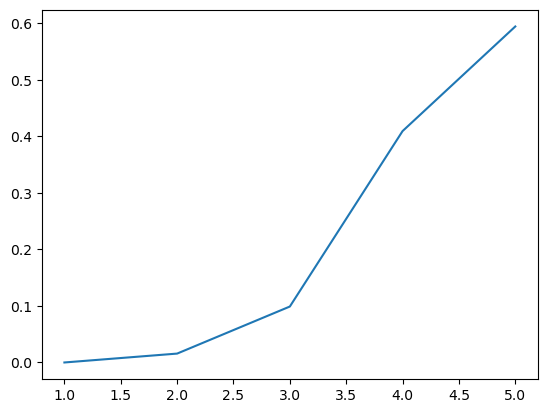

In [103]:
its = 5
T0a = tryIt(0,its,NewX,myJ,inc=True)
costs0 = [T0a[i][0] for i in range(its)]
print(costs0)
plt.plot([i+1 for i in range(its)], costs0)

[2.1664709493052214e-05, 9.807692549657077e-05, 0.00016898046305868775, 0.000780473870690912, 0.0006173355504870415]


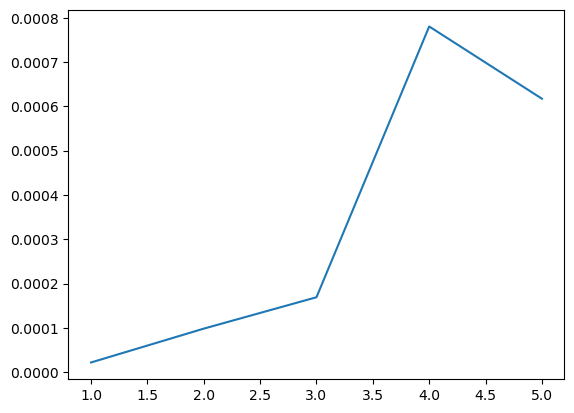

In [116]:
its = 5
T1a = tryIt(1,its,NewX,myJ,inc=False, n_epochs=5000)
costs1 = [T1a[i][0] for i in range(its)]
print(costs1)
plt.plot([i+1 for i in range(its)], costs1)

In [107]:
Costs1 = [0]
Costs1.extend(costs1)
Costs1

[0,
 4.680395795730874e-05,
 0.0021356192883104086,
 0.005347361322492361,
 0.0025073967408388853,
 0.00804133526980877]

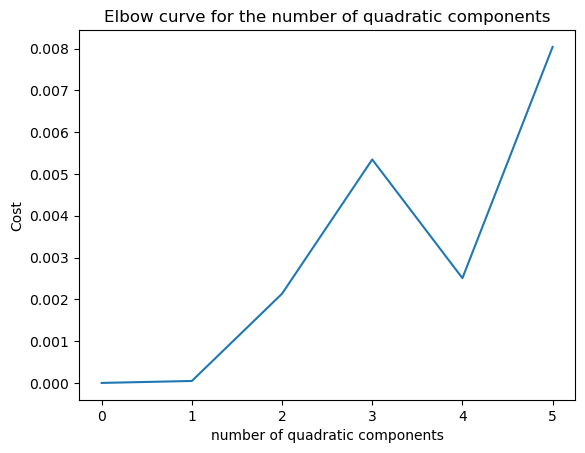

In [108]:
plt.plot([i for i in range(len(Costs1))], Costs1)
plt.xlabel("number of quadratic components")
plt.ylabel("Cost")
plt.title("Elbow curve for the number of quadratic components")
plt.show()

[413.47021484375, 361.88641357421875, 207.9222869873047, 130.9429168701172, 84.75484466552734]


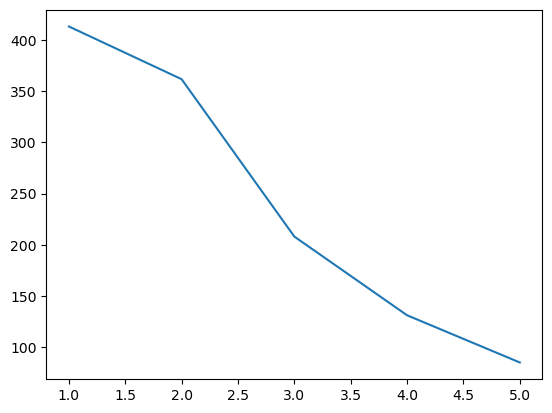

In [105]:
its = 5
T1a = tryIt(2,its,NewX,myJ,inc=True)
costs2 = [T1a[i][0] for i in range(its)]
print(costs2)
plt.plot([i+1 for i in range(its)], costs2)

In [221]:
poly3 = PolynomialFeatures(0)

In [222]:
B3 = poly3.fit_transform(NewX)

In [223]:
B3.shape

(8192, 1)

In [224]:
#B4 = np.array((NewX**2))

In [225]:
#B4.shape

In [226]:
extB3 = getExtendedFeatureMatrix2(B3,myJ,5)

In [227]:
extB3.shape

torch.Size([8192, 5])

In [228]:
#extB4 = getExtendedFeatureMatrix2(B4,myJ,5)

In [229]:
#extB4.shape

In [230]:
T1a = tryDimV(extB3, 1)

In [231]:
T2a = tryDimV(extB3, 2)

In [232]:
T3a = tryDimV(extB3, 3)

In [233]:
T4a = tryDimV(extB3, 4)

In [234]:
T5a = tryDimV(extB3, 5)

In [236]:
#T6a = tryDimV(extB3, 6)

In [237]:
theCosts = [T1a[0], T2a[0], T3a[0], T4a[0], T5a[0]]#, T6a[0]]

In [238]:
theCosts

[1.9401634290261427e-06,
 0.012226961553096771,
 0.20770461857318878,
 0.18405969440937042,
 0.2251235991716385]

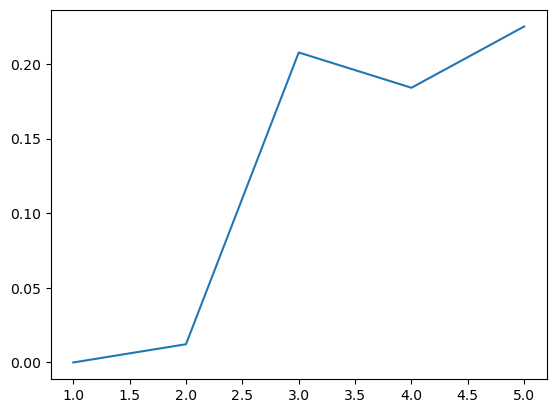

In [239]:
plt.plot([i+1 for i in range(len(theCosts))], theCosts)

In [199]:
poly3.get_feature_names_out()

array(['x0', 'x1', 'x2', 'x3', 'x4'], dtype=object)

In [200]:
T1a[1]

Parameter containing:
tensor([[-0.0145],
        [ 0.0785],
        [-0.2688],
        [ 0.2148],
        [ 0.0238],
        [ 0.1057],
        [-0.1530],
        [ 0.5162],
        [-0.4176],
        [-0.1844],
        [-0.1621],
        [-0.0408],
        [-0.0483],
        [-0.0857],
        [-0.1216],
        [-0.0262],
        [-0.0585],
        [ 0.2995],
        [-0.3340],
        [ 0.0146],
        [-0.0875],
        [ 0.0421],
        [ 0.1314],
        [ 0.2772],
        [ 0.0613]], requires_grad=True)

In [201]:
T2a[1]

Parameter containing:
tensor([[ 0.0039,  0.0174],
        [-0.0861,  0.0079],
        [-0.3953,  0.2333],
        [-0.0214,  0.0583],
        [-0.0900,  0.3936],
        [-0.0369, -0.4593],
        [ 0.2184,  0.0390],
        [ 0.3135,  0.0628],
        [-0.0552, -0.0487],
        [-0.0878, -0.1730],
        [ 0.0776,  0.1631],
        [ 0.0153,  0.0412],
        [-0.0703, -0.0597],
        [ 0.2185, -0.0538],
        [ 0.2717, -0.0760],
        [ 0.0473,  0.3311],
        [-0.0702,  0.0509],
        [ 0.3141,  0.1422],
        [ 0.0951,  0.3483],
        [ 0.2981, -0.3525],
        [ 0.0170,  0.0558],
        [ 0.0391,  0.0268],
        [-0.5402, -0.1152],
        [-0.0834, -0.3186],
        [-0.1803, -0.0322]], requires_grad=True)

In [115]:
t2

(9.063333417103081e-12,
 Parameter containing:
 tensor([[-5.7735e-01],
         [-1.0644e-07],
         [-3.0837e-08],
         [ 5.7735e-01],
         [ 5.1828e-06],
         [ 5.7735e-01]], requires_grad=True))

In [116]:
t2a

(0.06377208977937698,
 Parameter containing:
 tensor([[-1.6656e-01,  5.5282e-01],
         [-1.4722e-02, -4.3209e-03],
         [-2.1898e-03, -6.4226e-04],
         [ 1.5361e-01, -5.5662e-01],
         [ 9.5939e-01,  2.8141e-01],
         [ 1.6734e-01, -5.5259e-01]], requires_grad=True))

In [60]:
costs = []
for j in range(5):
    for i in range(1,3):
        exec("t" + str(i) + "= tryDim(B,i)[0]")
        costs.extend([eval("t" + str(i))])

In [50]:
costs

[2.045248735996208e-12,
 0.9993155002593994,
 2.045087406712942e-12,
 0.9993153810501099,
 2.0450876235533766e-12,
 0.9993153810501099,
 2.045087406712942e-12,
 0.999315619468689,
 2.2190617399164836e-12,
 0.9993153810501099]

In [51]:
Costs = np.array(costs)

In [52]:
Costs = Costs.reshape((5,2)) #Costs.reshape((5,6))

In [53]:
np.mean(Costs,axis=0)

array([2.07991458e-12, 9.99315453e-01])

In [54]:
np.mean(Costs,axis=1)

array([0.49965775, 0.49965769, 0.49965769, 0.49965781, 0.49965769])

In [55]:
Costs[0]

array([2.04524874e-12, 9.99315500e-01])

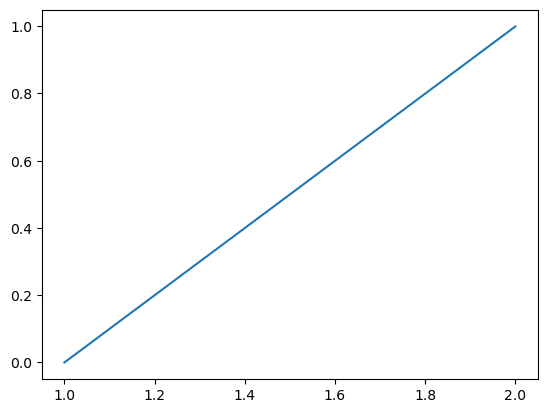

In [56]:
plt.plot([i+1 for i in range(len(Costs[0]))], np.mean(Costs,axis=0))

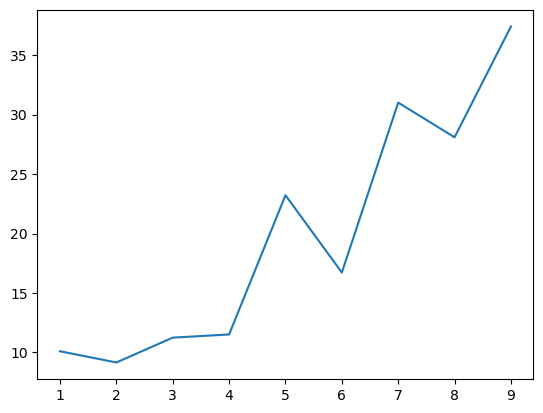

In [20]:
plt.plot([i for i in range(1,10)],costs)

In [21]:
costs2 = []
for i in range(1,10):
    exec("t" + str(i) + "= tryDim(B,i)")
    costs2.extend([eval("t" + str(i)).cost])

Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
   1         +1.3131534416419152e+02    1.41312149e+03    
   2         +9.4754768812155476e+01    1.30531343e+03    
   3         +5.2741508430205819e+01    4.10133006e+02    
   4         +5.0912014747569607e+01    6.22887170e+02    
   5         +4.6444807145352449e+01    2.12298153e+02    
   6         +4.3393384269000308e+01    5.36587369e+02    
   7         +4.0593207775745064e+01    2.01922172e+02    
   8         +3.9993290013087595e+01    4.13443019e+02    
   9         +3.8493355992770034e+01    1.53931332e+02    
  10         +3.6972964720110042e+01    4.00730172e+02    
  11         +3.5636938858050037e+01    1.74066856e+02    
  12         +3.5113436269825606e+01    2.65198238e+02    
  13         +3.4681684961828111e+01    2.90126388e+02    
  14         +3.3964322167376466e+01    1.81702472e+02    
  15         +3.3634382314281041e+01    3.

 157         +1.3068250120821261e+01    5.80277762e+01    
 158         +1.2954820005084276e+01    2.09674881e+02    
 159         +1.2921209887955543e+01    2.07595423e+02    
 160         +1.2824086652207857e+01    9.72893088e+01    
 161         +1.2792988761492850e+01    9.71079208e+01    
 162         +1.2777603832648124e+01    1.37420244e+02    
 163         +1.2732469724026249e+01    7.15442476e+01    
 164         +1.2706956953079144e+01    1.25677406e+02    
 165         +1.2657383893518041e+01    6.24928021e+01    
 166         +1.2617590203460887e+01    1.33868426e+02    
 167         +1.2575245580342916e+01    1.07469831e+02    
 168         +1.2536471257930346e+01    6.87261759e+01    
 169         +1.2507027128587282e+01    1.10198201e+02    
 170         +1.2475875078339079e+01    1.04871965e+02    
 171         +1.2455218954650192e+01    1.26034778e+02    
 172         +1.2407735756090467e+01    5.40106052e+01    
 173         +1.2228617430064640e+01    7.89498229e+01  

 307         +8.6654372098654839e+00    5.68784730e+01    
 308         +8.6543043310475838e+00    5.65239159e+01    
 309         +8.6432086329984408e+00    5.67725399e+01    
 310         +8.6321480078969337e+00    5.64050911e+01    
 311         +8.6211241149662285e+00    5.66680588e+01    
 312         +8.6101347870041440e+00    5.62871918e+01    
 313         +8.5991817508631190e+00    5.65650292e+01    
 314         +8.5882627782637009e+00    5.61702012e+01    
 315         +8.5773796652788867e+00    5.64634504e+01    
 316         +8.5665301208306772e+00    5.60541022e+01    
 317         +8.5557160118300271e+00    5.63633220e+01    
 318         +8.5449349826540963e+00    5.59388775e+01    
 319         +8.5341889726952758e+00    5.62646439e+01    
 320         +8.5234755600146830e+00    5.58245096e+01    
 321         +8.5127967581555080e+00    5.61674159e+01    
 322         +8.5021500770668172e+00    5.57109807e+01    
 323         +8.4915376061377472e+00    5.60716382e+01  

 472         +7.1849255275886792e+00    4.82299771e+01    
 473         +7.1775033702748834e+00    5.33190603e+01    
 474         +7.1700872327073437e+00    4.81303839e+01    
 475         +7.1626898694405963e+00    5.33470905e+01    
 476         +7.1552982665102185e+00    4.80307526e+01    
 477         +7.1479253176357469e+00    5.33768387e+01    
 478         +7.1405578727711845e+00    4.79311003e+01    
 479         +7.1332089608612153e+00    5.34082893e+01    
 480         +7.1258652998371765e+00    4.78314451e+01    
 481         +7.1185400497642144e+00    5.34414255e+01    
 482         +7.1112198007736467e+00    4.77318058e+01    
 483         +7.1039178397919169e+00    5.34762289e+01    
 484         +7.0966206335255624e+00    4.76322019e+01    
 485         +7.0893415913599416e+00    5.35126803e+01    
 486         +7.0820670610926220e+00    4.75326537e+01    
 487         +7.0748105700342965e+00    5.35507590e+01    
 488         +7.0675583517171701e+00    4.74331816e+01  

 684         +5.7884595070950704e+00    9.15772668e+01    
 685         +5.7821675624812876e+00    6.19965128e+01    
 686         +5.7758783418828568e+00    3.98083584e+01    
 687         +5.7696163562003493e+00    6.21236130e+01    
 688         +5.7695245613936557e+00    1.00256336e+02    
 689         +5.7691599483438560e+00    9.88561799e+01    
 690         +5.7677430041765376e+00    9.32505815e+01    
 691         +5.7627693739718611e+00    7.09466876e+01    
 692         +5.7561107722934555e+00    5.56834744e+01    
 693         +5.7507161262170943e+00    5.08995361e+01    
 694         +5.7454652615928961e+00    4.55744559e+01    
 695         +5.7402860530345388e+00    4.98925655e+01    
 696         +5.7402220480464576e+00    1.02484713e+02    
 697         +5.7399672346641673e+00    1.01519262e+02    
 698         +5.7389674308181444e+00    9.76538685e+01    
 699         +5.7352889581951381e+00    8.21839341e+01    
 700         +5.7263884461924857e+00    3.36552572e+01  

...

 178         +4.0269246807446791e+01    1.95290955e+02    
 179         +4.0064076054504618e+01    1.52476076e+02    
 180         +4.0031648789316101e+01    1.79138197e+02    
 181         +3.9916629275671262e+01    1.39110072e+02    
 182         +3.9746415234802498e+01    8.26718249e+01    
 183         +3.9710474472807782e+01    1.43433041e+02    
 184         +3.9593656668965224e+01    9.22273318e+01    
 185         +3.9493075866528159e+01    7.68216759e+01    
 186         +3.9402120085598156e+01    8.30240087e+01    
 187         +3.9391954566595132e+01    1.57507454e+02    
 188         +3.9353141407117946e+01    1.43271174e+02    
 189         +3.9229743506414366e+01    8.76738457e+01    
 190         +3.9141020489207136e+01    9.00267821e+01    
 191         +3.9107221438764810e+01    1.40291896e+02    
 192         +3.8997240717013881e+01    9.04941075e+01    
 193         +3.8900777842525471e+01    7.48495052e+01    
 194         +3.8813345881471257e+01    8.29421991e+01  

 373         +2.6770544690343019e+01    5.03581485e+01    
 374         +2.6743257752498547e+01    5.06563515e+01    
 375         +2.6716059177944334e+01    5.02319130e+01    
 376         +2.6688954459816934e+01    5.05465545e+01    
 377         +2.6661936803656953e+01    5.01065181e+01    
 378         +2.6635011913986720e+01    5.04381944e+01    
 379         +2.6608172800583681e+01    4.99819463e+01    
 380         +2.6581425384289386e+01    5.03312719e+01    
 381         +2.6554762473846690e+01    4.98581803e+01    
 382         +2.6528190211420604e+01    5.02257879e+01    
 383         +2.6501701199380371e+01    4.97352022e+01    
 384         +2.6475301806288265e+01    5.01217434e+01    
 385         +2.6448984422734537e+01    4.96129944e+01    
 386         +2.6422755648820694e+01    5.00191398e+01    
 387         +2.6396607657887600e+01    4.94915389e+01    
 388         +2.6370547286784671e+01    4.99179785e+01    
 389         +2.6344566486069429e+01    4.93708174e+01  

 569         +2.2618354412545553e+01    3.96768691e+01    
 570         +2.2601157413900580e+01    4.72167620e+01    
 571         +2.2583964365286580e+01    3.95788036e+01    
 572         +2.2566812463606432e+01    4.72541417e+01    
 573         +2.2549664103899321e+01    3.94813084e+01    
 574         +2.2532556494790576e+01    4.72923945e+01    
 575         +2.2515452032128159e+01    3.93843965e+01    
 576         +2.2498387925111192e+01    4.73314900e+01    
 577         +2.2481326581375580e+01    3.92880798e+01    
 578         +2.2464305199947550e+01    4.73713978e+01    
 579         +2.2447286210812194e+01    3.91923695e+01    
 580         +2.2430306792487610e+01    4.74120882e+01    
 581         +2.2413329407443214e+01    3.90972760e+01    
 582         +2.2396391203772200e+01    4.74535321e+01    
 583         +2.2379454686131936e+01    3.90028087e+01    
 584         +2.2362556962697141e+01    4.74957008e+01    
 585         +2.2345660589581804e+01    3.89089763e+01  

 751         +1.9866244345981290e+01    3.84048509e+01    
 752         +1.9853630523143512e+01    4.12106941e+01    
 753         +1.9841026250568525e+01    3.83582901e+01    
 754         +1.9828442064272636e+01    4.12124873e+01    
 755         +1.9815867263766101e+01    3.83116237e+01    
 756         +1.9803312496037140e+01    4.12147725e+01    
 757         +1.9790766949986782e+01    3.82648517e+01    
 758         +1.9778241383428984e+01    4.12175504e+01    
 759         +1.9765724874812012e+01    3.82179737e+01    
 760         +1.9753228292583199e+01    4.12208219e+01    
 761         +1.9740740604941912e+01    3.81709899e+01    
 762         +1.9728272790729420e+01    4.12245875e+01    
 763         +1.9715813708148325e+01    3.81239003e+01    
 764         +1.9703374446146508e+01    4.12288479e+01    
 765         +1.9690943753230993e+01    3.80767054e+01    
 766         +1.9678532828120318e+01    4.12336035e+01    
 767         +1.9666130309976932e+01    3.80294055e+01  

 921         +1.7892804005717839e+01    3.42853641e+01    
 922         +1.7881986826517071e+01    4.29626790e+01    
 923         +1.7871168611686468e+01    3.42390938e+01    
 924         +1.7860364976266268e+01    4.29979359e+01    
 925         +1.7849560240167587e+01    3.41929637e+01    
 926         +1.7838770011101023e+01    4.30333918e+01    
 927         +1.7827978617632688e+01    3.41469755e+01    
 928         +1.7817201659094618e+01    4.30690424e+01    
 929         +1.7806423473738118e+01    3.41011306e+01    
 930         +1.7795659651500472e+01    4.31048832e+01    
 931         +1.7784894541315502e+01    3.40554303e+01    
 932         +1.7774143722741989e+01    4.31409100e+01    
 933         +1.7763391556360897e+01    3.40098760e+01    
 934         +1.7752653610400813e+01    4.31771185e+01    
 935         +1.7741914258022284e+01    3.39644688e+01    
 936         +1.7731189055203757e+01    4.32135046e+01    
 937         +1.7720462388585847e+01    3.39192099e+01  

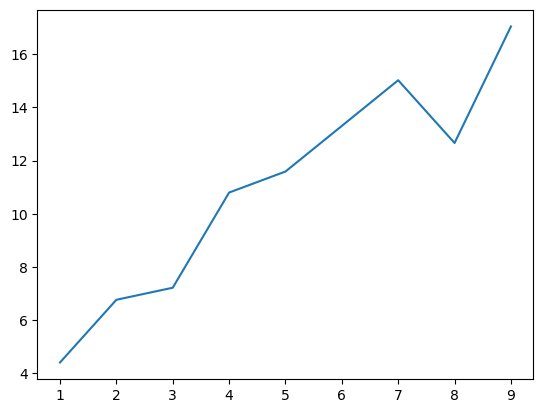

In [22]:
plt.plot([i for i in range(1,10)],costs2)

In [46]:
#myManRes = []
#for i in range(5):
#    myManres = tryDim(6)
#    myManRes.extend([myManres.point])
#    
#myManRes = sum(myManRes)/5

In [47]:
myManRes1 = tryDim(B,6)

Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
   1         +2.4049116487374202e-02    5.99850282e-02    
   2         +1.1742248478368290e-02    5.16279871e-02    
   3         +9.5543762164706173e-03    4.93234675e-02    
   4         +7.7410801502509974e-03    4.42477433e-02    
   5         +5.7198882986675146e-03    1.56947809e-02    
   6         +5.3232942332709773e-03    3.75130733e-02    
   7         +4.4119148250749340e-03    8.23336849e-03    
   8         +4.1995890089597350e-03    4.54564576e-02    
   9         +3.4757727962338131e-03    3.08640009e-02    
  10         +3.3831492272908318e-03    3.23417690e-02    
  11         +3.0842007188889593e-03    1.96535549e-02    
  12         +3.0541079066918777e-03    2.50102434e-02    
  13         +2.9478365028906273e-03    1.91698908e-02    
  14         +2.8426346524236465e-03    1.67878383e-02    
  15         +2.8285090803379311e-03    2.

 150         +1.3195050697657224e-03    2.14438611e-03    
 151         +1.3171776863541789e-03    4.41543540e-03    
 152         +1.3143662981489404e-03    3.31471542e-03    
 153         +1.3122820885626012e-03    2.89572640e-03    
 154         +1.3103207641498027e-03    2.50521288e-03    
 155         +1.3084345068924792e-03    2.77543311e-03    
 156         +1.3083510448739775e-03    5.49859223e-03    
 157         +1.3080229936684655e-03    5.30804160e-03    
 158         +1.3068061598321683e-03    4.54490816e-03    
 159         +1.3036496775580412e-03    1.94182214e-03    
 160         +1.3001742292257062e-03    7.60685015e-03    
 161         +1.2918868844129427e-03    2.08815631e-03    
 162         +1.2907290851713496e-03    6.37004683e-03    
 163         +1.2869693917776997e-03    4.03194708e-03    
 164         +1.2844844134313432e-03    3.02188173e-03    
 165         +1.2826794515545109e-03    2.96679168e-03    
 166         +1.2822676311592645e-03    4.99599202e-03  

 290         +1.0977641287305837e-03    2.08322111e-03    
 291         +1.0965359735039724e-03    2.47259160e-03    
 292         +1.0953082892347454e-03    2.07529897e-03    
 293         +1.0940851005937411e-03    2.47540049e-03    
 294         +1.0928623192143513e-03    2.06740126e-03    
 295         +1.0916439875544078e-03    2.47831071e-03    
 296         +1.0904260018200138e-03    2.05953152e-03    
 297         +1.0892124193748369e-03    2.48131770e-03    
 298         +1.0879991238880358e-03    2.05169313e-03    
 299         +1.0867901848340010e-03    2.48441689e-03    
 300         +1.0855814761377399e-03    2.04388930e-03    
 301         +1.0843770766865441e-03    2.48760371e-03    
 302         +1.0831728533459897e-03    2.03612301e-03    
 303         +1.0819728918251743e-03    2.49087366e-03    
 304         +1.0807730544982826e-03    2.02839708e-03    
 305         +1.0795774314194850e-03    2.49422229e-03    
 306         +1.0783818829162161e-03    2.02071410e-03  

 433         +9.4566329039180773e-04    4.11551739e-03    
 434         +9.4506438716292262e-04    3.43831035e-03    
 435         +9.4365995404694313e-04    1.41703645e-03    
 436         +9.3805595064607459e-04    1.41468507e-03    
 437         +9.1935712518957365e-04    6.01546688e-03    
 438         +9.1579013352665435e-04    2.27583741e-03    
 439         +9.1498887572578208e-04    1.93637062e-03    
 440         +9.1423781340078654e-04    2.10690338e-03    
 441         +9.1417772767339383e-04    4.12114260e-03    
 442         +9.1394503848162391e-04    3.85976864e-03    
 443         +9.1314299623257628e-04    2.82170511e-03    
 444         +9.1243862861759711e-04    2.93650713e-03    
 445         +9.1144902078419733e-04    2.21099492e-03    
 446         +9.1071801280707043e-04    2.30218309e-03    
 447         +9.1043584719193999e-04    3.62362714e-03    
 448         +9.0951879263936257e-04    2.33230545e-03    
 449         +9.0871405805046323e-04    1.93886058e-03  

 581         +8.2281219064287553e-04    1.78302029e-03    
 582         +8.2222190877425088e-04    1.87329513e-03    
 583         +8.2163230578338276e-04    1.78052830e-03    
 584         +8.2104382258062149e-04    1.87278477e-03    
 585         +8.2045600794208775e-04    1.77803084e-03    
 586         +8.1986930935052608e-04    1.87230282e-03    
 587         +8.1928326901326975e-04    1.77552781e-03    
 588         +8.1869834101754577e-04    1.87184944e-03    
 589         +8.1811406097000606e-04    1.77301911e-03    
 590         +8.1753088959194569e-04    1.87142480e-03    
 591         +8.1694835586002695e-04    1.77050466e-03    
 592         +8.1636692715658036e-04    1.87102910e-03    
 593         +8.1578612580167299e-04    1.76798438e-03    
 594         +8.1520642586290328e-04    1.87066249e-03    
 595         +8.1462734297996220e-04    1.76545822e-03    
 596         +8.1404935792709417e-04    1.87032513e-03    
 597         +8.1347197964277637e-04    1.76292612e-03  

 726         +7.4490887139537856e-04    1.91161995e-03    
 727         +7.4441370509056469e-04    1.59100816e-03    
 728         +7.4391936386723257e-04    1.91309468e-03    
 729         +7.4342505453992610e-04    1.58843186e-03    
 730         +7.4293156526845613e-04    1.91458726e-03    
 731         +7.4243810233267206e-04    1.58586408e-03    
 732         +7.4194545442578285e-04    1.91609731e-03    
 733         +7.4145282741066470e-04    1.58330505e-03    
 734         +7.4096101039811655e-04    1.91762442e-03    
 735         +7.4046920894898464e-04    1.58075496e-03    
 736         +7.3997821247860217e-04    1.91916818e-03    
 737         +7.3948722635788463e-04    1.57821404e-03    
 738         +7.3899704019645188e-04    1.92072822e-03    
 739         +7.3850685928449707e-04    1.57568248e-03    
 740         +7.3801747331853919e-04    1.92230413e-03    
 741         +7.3752808761431304e-04    1.57316046e-03    
 742         +7.3703949185074805e-04    1.92389553e-03  

 874         +6.7519464428393745e-04    2.04906880e-03    
 875         +6.7474157858485252e-04    1.42948060e-03    
 876         +6.7428903718591299e-04    2.05113263e-03    
 877         +6.7383633335742806e-04    1.42768840e-03    
 878         +6.7338414103705678e-04    2.05319780e-03    
 879         +6.7293179575617307e-04    1.42595334e-03    
 880         +6.7247998123798423e-04    2.05526893e-03    
 881         +6.7202799014234817e-04    1.42412222e-03    
 882         +6.7157647767026685e-04    2.05733421e-03    
 883         +6.7112483920248728e-04    1.42253693e-03    
 884         +6.7067378864266332e-04    2.05942310e-03    
 885         +6.7067342090148835e-04    3.50675567e-03    
 886         +6.7067195047770291e-04    3.50417672e-03    
 887         +6.7066607744207868e-04    3.49386031e-03    
 888         +6.7064272416524388e-04    3.45258534e-03    
 889         +6.7055155315625292e-04    3.28737905e-03    
 890         +6.7022408718687379e-04    2.62868381e-03  

In [48]:
myManRes2 = tryDim(newB2,6)

Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
   1         +4.2079959962254644e-02    4.97386375e-02    
   2         +7.6203756638077557e-03    5.00200304e-02    
   3         +7.1248610008393942e-03    4.78714190e-02    
   4         +5.4523666383988773e-03    3.06867343e-02    
   5         +4.8899478084173578e-03    1.36904251e-02    
   6         +4.7734379334730750e-03    5.92076082e-03    
   7         +4.7389102288471667e-03    9.09895821e-03    
   8         +4.6814296873839761e-03    5.88246386e-03    
   9         +4.6493047080260683e-03    9.25364354e-03    
  10         +4.5905082911657366e-03    5.25154397e-03    
  11         +4.5555134629699200e-03    1.01537213e-02    
  12         +4.4890618697497149e-03    4.88005007e-03    
  13         +4.4515055023668527e-03    1.16384703e-02    
  14         +4.3705085842365527e-03    4.16714517e-03    
  15         +4.1353425255304180e-03    1.

 142         +2.2223542013027034e-03    2.08955509e-03    
 143         +2.1615127147098737e-03    2.11095903e-02    
 144         +2.0448361127247709e-03    2.61158863e-03    
 145         +2.0437360804357128e-03    6.13923266e-03    
 146         +2.0398112460991392e-03    4.83337733e-03    
 147         +2.0332462708889903e-03    2.67236890e-03    
 148         +2.0313395898220641e-03    5.45065467e-03    
 149         +2.0254842955016962e-03    3.08065821e-03    
 150         +2.0226293911707401e-03    4.24649467e-03    
 151         +2.0171508175216724e-03    2.35043174e-03    
 152         +2.0127337751647809e-03    4.46687016e-03    
 153         +2.0083553242676491e-03    4.02462140e-03    
 154         +2.0060543837954184e-03    4.94497237e-03    
 155         +1.9999302073148923e-03    2.18263180e-03    
 156         +1.9991069632326885e-03    9.30665557e-03    
 157         +1.9959389216386201e-03    8.60130372e-03    
 158         +1.9854344362222119e-03    5.69397833e-03  

 303         +1.3977217362210644e-03    1.10362681e-02    
 304         +1.3780697274588679e-03    2.66512355e-03    
 305         +1.3765274430510878e-03    2.90621663e-03    
 306         +1.3752349395166588e-03    3.45215713e-03    
 307         +1.3727984938291977e-03    1.90815044e-03    
 308         +1.3710134415446285e-03    3.68212939e-03    
 309         +1.3686280943610049e-03    2.64408322e-03    
 310         +1.3671006093780782e-03    2.85763074e-03    
 311         +1.3659240710246765e-03    3.53968443e-03    
 312         +1.3634214053108739e-03    1.67258531e-03    
 313         +1.3593336279959286e-03    5.74987598e-03    
 314         +1.3546991367462012e-03    3.42915990e-03    
 315         +1.3545058154867601e-03    4.76907586e-03    
 316         +1.3537691985654303e-03    4.31955963e-03    
 317         +1.3514562387676385e-03    2.56534124e-03    
 318         +1.3500374067818481e-03    2.92314654e-03    
 319         +1.3485990300614720e-03    3.12464018e-03  

 444         +1.1507858645199032e-03    1.89414023e-03    
 445         +1.1498157665776863e-03    1.90012538e-03    
 446         +1.1488482325152313e-03    1.89047883e-03    
 447         +1.1478833524901845e-03    1.89674789e-03    
 448         +1.1469210142233139e-03    1.88682650e-03    
 449         +1.1459613108917878e-03    1.89338860e-03    
 450         +1.1450041273131590e-03    1.88318312e-03    
 451         +1.1440495597591555e-03    1.89004768e-03    
 452         +1.1430974900671707e-03    1.87954860e-03    
 453         +1.1421480176800932e-03    1.88672530e-03    
 454         +1.1412010213766315e-03    1.87592283e-03    
 455         +1.1402566038490195e-03    1.88342164e-03    
 456         +1.1393146407371591e-03    1.87230571e-03    
 457         +1.1383752380624168e-03    1.88013687e-03    
 458         +1.1374382682441462e-03    1.86869711e-03    
 459         +1.1365038407142539e-03    1.87687118e-03    
 460         +1.1355718245881694e-03    1.86509692e-03  

 601         +1.0247606714337582e-03    1.70960788e-03    
 602         +1.0240944788233635e-03    1.61903548e-03    
 603         +1.0234299760540240e-03    1.70845481e-03    
 604         +1.0227664792832694e-03    1.61549842e-03    
 605         +1.0221046651985230e-03    1.70734450e-03    
 606         +1.0214438377881324e-03    1.61195453e-03    
 607         +1.0207846859406229e-03    1.70627729e-03    
 608         +1.0201265014364192e-03    1.60840379e-03    
 609         +1.0194699853971587e-03    1.70525350e-03    
 610         +1.0188144173665396e-03    1.60484620e-03    
 611         +1.0181605107212786e-03    1.70427342e-03    
 612         +1.0175075327499500e-03    1.60128179e-03    
 613         +1.0168562090958273e-03    1.70333735e-03    
 614         +1.0162057947848231e-03    1.59771061e-03    
 615         +1.0155570277273118e-03    1.70244555e-03    
 616         +1.0149091506903203e-03    1.59413273e-03    
 617         +1.0142629138405080e-03    1.70159828e-03  

 753         +9.3535050429055598e-04    1.73525208e-03    
 754         +9.3481790055312242e-04    1.35569266e-03    
 755         +9.3428629441875293e-04    1.73660725e-03    
 756         +9.3375464204097981e-04    1.35278152e-03    
 757         +9.3322397774031000e-04    1.73797202e-03    
 758         +9.3269326228966900e-04    1.34989336e-03    
 759         +9.3216352547422561e-04    1.73934594e-03    
 760         +9.3163373277736241e-04    1.34702820e-03    
 761         +9.3110490935920814e-04    1.74072858e-03    
 762         +9.3057602549800075e-04    1.34418604e-03    
 763         +9.3004810164561082e-04    1.74211950e-03    
 764         +9.2952011295313792e-04    1.34136688e-03    
 765         +9.2899307508721393e-04    1.74351832e-03    
 766         +9.2846596814364886e-04    1.33857070e-03    
 767         +9.2793980293284762e-04    1.74492463e-03    
 768         +9.2741356456129071e-04    1.33579746e-03    
 769         +9.2688825891791820e-04    1.74633807e-03  

 905         +8.5676203483779222e-04    1.79689067e-03    
 906         +8.5662069768735862e-04    2.67774403e-03    
 907         +8.5615052788706541e-04    1.81278291e-03    
 908         +8.5612984807480435e-04    2.96382109e-03    
 909         +8.5604884141921109e-04    2.84143333e-03    
 910         +8.5575309680028459e-04    2.35276712e-03    
 911         +8.5508505731252387e-04    1.01019178e-03    
 912         +8.5272671235084058e-04    1.91117482e-03    
 913         +8.5223811269147080e-04    1.41196360e-03    
 914         +8.5185835173843887e-04    1.75748070e-03    
 915         +8.5160354070932295e-04    2.33359995e-03    
 916         +8.5097373831540110e-04    1.00777469e-03    
 917         +8.4873968893621910e-04    1.84325788e-03    
 918         +8.4827437801437186e-04    1.41718401e-03    
 919         +8.4789063541421833e-04    1.66683282e-03    
 920         +8.4772420660126323e-04    2.57195602e-03    
 921         +8.4720137339037809e-04    1.53924329e-03  

In [49]:
myManRes1.point.shape

(66, 6)

In [50]:
myManRes2.point.shape

(21, 6)

In [51]:
testtrans = poly.transform(np.array([[5,5,5,5,0,0,0,0,0,0]]))
testtrans.shape

(1, 66)

In [52]:
np.linalg.norm(testtrans@myManRes1.point)

30.339898052788964

In [54]:
thingy1 = B@myManRes1.point
thingy1.shape

(65536, 6)

In [55]:
thingy2 = newB2@myManRes2.point
thingy2.shape

(65536, 6)

In [56]:
vals1 = [np.linalg.norm(thing) for thing in thingy1]
vals2 = [np.linalg.norm(thing) for thing in thingy2]

In [58]:
np.mean(vals1)

0.1451115799220752

In [59]:
np.mean(vals2)

0.18322035553663074

In [60]:
np.std(vals1)

0.06877132913820728

In [61]:
np.std(vals2)

0.09543882688185922

In [176]:
class invf():
    def __init__(self,W,featFunc,X):
        self.ds = X
        self.params = W
        self.featFunc = featFunc
        
        
    def f(self,Y):
        w = self.params
        trans = self.featFunc.transform(Y)
        term = trans@w
        #term = w[0]*x[0]**2 + w[1]*x[0] + w[2]*x[1]**2 + w[3]*x[1] + w[4]*x[2]**2 + w[5]*x[2] + w[6] # missing x*y.
        return term
    
    
    def jacf(self,x): #Jacobian at a single point.
        #w = self.params
        dim = self.featFunc.n_features_in_
        from sympy import symbols
        from sympy import Matrix
        from sympy import lambdify
        # create sympy symbols.
        exec(",".join(list(self.featFunc.get_feature_names_out()[1:dim+1])) + '= symbols(" ".join(list(self.featFunc.get_feature_names_out()[1:dim+1])))')
        # Fix things: no x0^2 and such.
        p1 = ",".join(list(self.featFunc.get_feature_names_out()))
        p2 = p1.replace(" ", "*")
        p3 = p2.replace("^", "**")
        p3a = list(eval(p3))
        p4 = Matrix(p3a)
        # Define the jacobian and make it a numpy array.
        J = p4.jacobian(Matrix(p3a[1:dim+1]))
        #print(J)
        Jnp = lambdify([p3a[1:dim+1]],J)
        print(self.params.transpose()@J)
        realJ = self.params.transpose()@Jnp(x)
        return realJ
    
    
    def Jacf(self,X): #stacked Jacobian matrix at each point in X
        #w = self.params
        dim = self.featFunc.n_features_in_
        from sympy import symbols
        from sympy import Matrix
        from sympy import lambdify
        # create sympy symbols.
        exec(",".join(list(self.featFunc.get_feature_names_out()[1:dim+1])) + '= symbols(" ".join(list(self.featFunc.get_feature_names_out()[1:dim+1])))')
        # Fix things: no x0^2 and such.
        p1 = ",".join(list(self.featFunc.get_feature_names_out()))
        p2 = p1.replace(" ", "*")
        p3 = p2.replace("^", "**")
        p3a = list(eval(p3))
        p4 = Matrix(p3a)
        # Define the jacobian and make it a numpy array.
        J = p4.jacobian(Matrix(p3a[1:dim+1]))
        Jnp = lambdify([p3a[1:dim+1]],J)        
        
        
        jacs = []
        for x in X:
            jacs.extend([self.params.transpose()@Jnp(x)])
            
        bigJ = np.array(jacs) #np.vstack(jacs)
        return bigJ
    
    
    def getfunc(self):
        return self.f
    
    
    def getgrad(self):
        return self.gradf
    
    
    def getParams(self):
        return self.params
    
    
    def getDS(self):
        return self.ds

In [63]:
poly.get_feature_names_out()

array(['1', 'x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9',
       'x0^2', 'x0 x1', 'x0 x2', 'x0 x3', 'x0 x4', 'x0 x5', 'x0 x6',
       'x0 x7', 'x0 x8', 'x0 x9', 'x1^2', 'x1 x2', 'x1 x3', 'x1 x4',
       'x1 x5', 'x1 x6', 'x1 x7', 'x1 x8', 'x1 x9', 'x2^2', 'x2 x3',
       'x2 x4', 'x2 x5', 'x2 x6', 'x2 x7', 'x2 x8', 'x2 x9', 'x3^2',
       'x3 x4', 'x3 x5', 'x3 x6', 'x3 x7', 'x3 x8', 'x3 x9', 'x4^2',
       'x4 x5', 'x4 x6', 'x4 x7', 'x4 x8', 'x4 x9', 'x5^2', 'x5 x6',
       'x5 x7', 'x5 x8', 'x5 x9', 'x6^2', 'x6 x7', 'x6 x8', 'x6 x9',
       'x7^2', 'x7 x8', 'x7 x9', 'x8^2', 'x8 x9', 'x9^2'], dtype=object)

In [64]:
def testFunc(x):
    c1 = x[4] - 2*x[0]
    c2 = x[5]+x[0]-x[1]**2 - x[2]**2
    c3 = x[6]-4
    c4 = x[7]
    c5 = x[8]-x[0]+x[3]
    c6 = x[9]-1
    vec = np.array([c1,c2,c3,c4,c5,c6])
    return vec

In [19]:
mt1 = np.array([testFunc(x) for x in X])

In [20]:
mt1

array([[ 0.00000000e+00, -1.08897266e-14,  0.00000000e+00,
         0.00000000e+00, -6.66133815e-15,  0.00000000e+00],
       [-9.76996262e-15, -3.10862447e-14,  0.00000000e+00,
         0.00000000e+00, -7.10542736e-15,  0.00000000e+00],
       [ 0.00000000e+00, -1.59872116e-14,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  1.90958360e-14,  0.00000000e+00,
         0.00000000e+00,  1.88737914e-15,  0.00000000e+00],
       [ 0.00000000e+00, -6.27276009e-15,  0.00000000e+00,
         0.00000000e+00, -6.66133815e-15,  0.00000000e+00],
       [ 9.99200722e-16, -1.37667655e-14,  0.00000000e+00,
         0.00000000e+00, -1.99840144e-15,  0.00000000e+00]])

In [22]:
np.mean(mt1.transpose()[0])

1.750627677614364e-18

In [23]:
np.mean(mt1.transpose()[1])

1.0182613608370026e-16

In [24]:
np.mean(mt1.transpose()[2])

0.0

In [25]:
np.mean(mt1.transpose()[3])

0.0

In [26]:
np.mean(mt1.transpose()[4])

2.2341440045808385e-17

In [27]:
np.mean(mt1.transpose()[5])

0.0

In [74]:
eq1 = [0,-2,0,0,0,1]
eq2 = [0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-1,0,0,0,0,0,0,0,0,-1]
eq3 = [-4,0,0,0,0,0,0,1]
eq4 = [0,0,0,0,0,0,0,0,1]
eq5 = [0,-1,0,0,1,0,0,0,0,1]
eq6 = [-1,0,0,0,0,0,0,0,0,0,1]

In [75]:
eq1.extend(np.zeros(66-len(eq1)))
eq2.extend(np.zeros(66-len(eq2)))
eq3.extend(np.zeros(66-len(eq3)))
eq4.extend(np.zeros(66-len(eq4)))
eq5.extend(np.zeros(66-len(eq5)))
eq6.extend(np.zeros(66-len(eq6)))

In [76]:
testMat = np.array([eq1,eq2,eq3,eq4,eq5,eq6])

In [177]:
testf = invf(testMat.transpose(), poly, X)

In [32]:
mt2 = testf.f(X)

In [33]:
mt3 = mt1 - mt2

In [36]:
np.mean(np.unique(mt3))

2.008885690576973e-17

In [65]:
Myf = invf(myManRes1.point, poly, X)

In [122]:
testX = np.array([0,0,0,0,0,0,4,0,0,1])

In [123]:
testf.f(np.array([testX]))

array([[0., 0., 0., 0., 0., 0.]])

In [124]:
Myf.f(np.array([testX]))

array([[-0.02057753, -0.00358812, -0.01638383,  0.05970129, -0.03474796,
         0.03887534]])

In [178]:
testf.jacf(testX)

Matrix([[-2.00000000000000, 0, 0, 0, 1.00000000000000, 0, 0, 0, 0, 0], [1.00000000000000, -2.0*x1, -2.0*x2, 0, 0, 1.00000000000000, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1.00000000000000, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 1.00000000000000, 0, 0], [-1.00000000000000, 0, 0, 1.00000000000000, 0, 0, 0, 0, 1.00000000000000, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 1.00000000000000]])


array([[-2.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.],
       [ 1.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.],
       [-1.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  1.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]])

In [68]:
TESTJ = Myf.Jacf(X)

In [71]:
TESTJ.shape

(65536, 6, 10)

In [78]:
ControlJ = testf.Jacf(X)

In [79]:
poly2 = PolynomialFeatures(2, include_bias=False)

In [80]:
B2 = poly2.fit_transform(X) # Potentially different features in the vector fields than the level set components.

In [81]:
newB.shape

(65536, 20)

In [82]:
# This is a memory hog. Can we fix this later?
def getExtendedFeatureMatrix(B,J,dim):
    n = B.shape[0]
    m = B.shape[1]
    ExtArray = []
    for j in range(n):
        newBthing = np.append(B[j],np.zeros((dim-1)*m))
        Barray = np.array([np.roll(newBthing,i*m) for i in range(dim)])
        thing = np.dot(J[j],Barray)
        ExtArray.extend(thing)
        
    ExtArray = np.array(ExtArray)
    return ExtArray

In [83]:
extB2 = getExtendedFeatureMatrix(newB,TESTJ,10) #getExtendedFeatureMatrix(B2,TESTJ,10)

In [84]:
extB2.shape

(393216, 200)

In [85]:
ControlExtB2 = getExtendedFeatureMatrix(newB,ControlJ,10) #getExtendedFeatureMatrix(B2,ControlJ,10)

In [188]:
poly0 = PolynomialFeatures(0)

In [190]:
Bc = poly0.fit_transform(X)

In [193]:
Bc.shape

(65536, 1)

In [194]:
ControlBc = getExtendedFeatureMatrix(Bc,ControlJ,10)

In [205]:
extBc = getExtendedFeatureMatrix(Bc,TESTJ,10)

In [195]:
ControlBc.shape

(393216, 10)

In [86]:
def getProdMan(extB2, dim, num):
    manifolds = []
    manifold0 = pymanopt.manifolds.stiefel.Stiefel(extB2.shape[1],num)
    manifolds.extend([manifold0])
    for i in range(1,num+1):
        exec("manifold" + str(i) + "=pymanopt.manifolds.euclidean.Euclidean(dim)")
        exec("manifolds.extend([manifold" + str(i) + "])")
        
    ProdManifold = pymanopt.manifolds.product.Product(manifolds)
    return ProdManifold

In [87]:
'''ProdManifold = getProdMan(extB2, 10, 10)'''

'ProdManifold = getProdMan(extB2, 10, 10)'

In [88]:
'''@pymanopt.function.autograd(ProdManifold)
def myCost(*args): #mat2 is more like a vector, even in general.
    vs = args[1:] #list(locals().values())[1:]
    dim = vs[0].shape[0]
    numfeats = args[0].shape[0]+dim

    #First, get a rearranged matrix V so we can multiply it with the A matrix (extB)
    term1 = extB2@args[0] #mat1
    # Now we need to multiply it (the transpose) with extB
    #term1 = extB2 @ bigV.transpose()
    term2 = anp.mean(term1, axis=0) # mean for each column
    term3 = anp.array([sum(v) for v in vs]) # "bias correction"
    term4 = anp.linalg.norm(term2-term3) # should be close-ish to zero in the end.
    return term4'''

'@pymanopt.function.autograd(ProdManifold)\ndef myCost(*args): #mat2 is more like a vector, even in general.\n    vs = args[1:] #list(locals().values())[1:]\n    dim = vs[0].shape[0]\n    numfeats = args[0].shape[0]+dim\n\n    #First, get a rearranged matrix V so we can multiply it with the A matrix (extB)\n    term1 = extB2@args[0] #mat1\n    # Now we need to multiply it (the transpose) with extB\n    #term1 = extB2 @ bigV.transpose()\n    term2 = anp.mean(term1, axis=0) # mean for each column\n    term3 = anp.array([sum(v) for v in vs]) # "bias correction"\n    term4 = anp.linalg.norm(term2-term3) # should be close-ish to zero in the end.\n    return term4'

In [89]:
'''problem = pymanopt.Problem(ProdManifold, myCost)

optimizer = pymanopt.optimizers.SteepestDescent()
result = optimizer.run(problem)'''

'problem = pymanopt.Problem(ProdManifold, myCost)\n\noptimizer = pymanopt.optimizers.SteepestDescent()\nresult = optimizer.run(problem)'

In [90]:
'''result.cost'''

'result.cost'

In [91]:
'''@pymanopt.function.autograd(ProdManifold)
def myCost(*args): #mat2 is more like a vector, even in general.
    vs = args[1:] #list(locals().values())[1:]
    dim = vs[0].shape[0]
    numfeats = args[0].shape[0]+dim

    #First, get a rearranged matrix V so we can multiply it with the A matrix (extB)
    term1 = extB2@args[0] #mat1
    # Now we need to multiply it (the transpose) with extB
    #term2 = anp.linalg.norm(term1, axis=0) #anp.mean(term1, axis=0) # mean for each column
    #term3 = anp.array([sum(v) for v in vs]) # "bias correction"
    term2 = anp.array([sum(v) for v in vs])
    term3 = anp.add(term1,term2)
    #print(term3.shape)
    term4 = anp.linalg.norm(term3, axis=0)
    #print(term4)
    term5 = anp.linalg.norm(term4)
    #term4 = anp.linalg.norm(term2-term3) # should be close-ish to zero in the end.
    return term5'''

'@pymanopt.function.autograd(ProdManifold)\ndef myCost(*args): #mat2 is more like a vector, even in general.\n    vs = args[1:] #list(locals().values())[1:]\n    dim = vs[0].shape[0]\n    numfeats = args[0].shape[0]+dim\n\n    #First, get a rearranged matrix V so we can multiply it with the A matrix (extB)\n    term1 = extB2@args[0] #mat1\n    # Now we need to multiply it (the transpose) with extB\n    #term2 = anp.linalg.norm(term1, axis=0) #anp.mean(term1, axis=0) # mean for each column\n    #term3 = anp.array([sum(v) for v in vs]) # "bias correction"\n    term2 = anp.array([sum(v) for v in vs])\n    term3 = anp.add(term1,term2)\n    #print(term3.shape)\n    term4 = anp.linalg.norm(term3, axis=0)\n    #print(term4)\n    term5 = anp.linalg.norm(term4)\n    #term4 = anp.linalg.norm(term2-term3) # should be close-ish to zero in the end.\n    return term5'

In [92]:
'''problem = pymanopt.Problem(ProdManifold, myCost)
optimizer = pymanopt.optimizers.SteepestDescent(max_iterations=20)
result = optimizer.run(problem)'''

'problem = pymanopt.Problem(ProdManifold, myCost)\noptimizer = pymanopt.optimizers.SteepestDescent(max_iterations=20)\nresult = optimizer.run(problem)'

In [50]:
def costFromNum(extB2, extBc, dim, num):
    ProdManifold = getProdMan(extB2, dim, num)
    
    @pymanopt.function.autograd(ProdManifold)
    def myCost(*args): #mat2 is more like a vector, even in general.
        vs = args[1:] #list(locals().values())[1:]
        dim = vs[0].shape[0]
        numfeats = args[0].shape[0]+dim

        #First, get a rearranged matrix V so we can multiply it with the A matrix (extB)
        term1 = extB2@args[0] #mat1
        # Now we need to multiply it (the transpose) with extB
        #term2 = anp.linalg.norm(term1, axis=0) #anp.mean(term1, axis=0) # mean for each column
        #term3 = anp.array([sum(v) for v in vs]) # "bias correction"
        term2 = anp.array([extBc@v for v in vs]) #anp.array([sum(v) for v in vs])
        term3 = anp.add(term1,term2.transpose())
        term4 = anp.linalg.norm(term3, axis=0)
        term5 = anp.linalg.norm(term4)
        #term4 = anp.linalg.norm(term2-term3) # should be close-ish to zero in the end.
        return term5
    
    problem = pymanopt.Problem(ProdManifold, myCost)
    optimizer = pymanopt.optimizers.SteepestDescent() #pymanopt.optimizers.SteepestDescent(max_iterations=50)
    result = optimizer.run(problem)
    
    return result.cost

In [110]:
ProdManifold = getProdMan(extB2, 10, 4)

In [202]:
@pymanopt.function.autograd(ProdManifold)
def myCost(*args): #mat2 is more like a vector, even in general.
    vs = args[1:] #list(locals().values())[1:]
    dim = vs[0].shape[0]
    numfeats = args[0].shape[0]+dim

    #First, get a rearranged matrix V so we can multiply it with the A matrix (extB)
    term1 = ControlExtB2@args[0] #mat1
    # Now we need to multiply it (the transpose) with extB
    #term2 = anp.linalg.norm(term1, axis=0) #anp.mean(term1, axis=0) # mean for each column
    #term3 = anp.array([sum(v) for v in vs]) # "bias correction"
    term2 = anp.array([ControlBc@v for v in vs]) #anp.array([sum(v) for v in vs])
    term3 = anp.add(term1,term2.transpose())
    term4 = anp.linalg.norm(term3, axis=0)
    term5 = anp.linalg.norm(term4)
    #term4 = anp.linalg.norm(term2-term3) # should be close-ish to zero in the end.
    return term5

In [163]:
eqn1 = [1,0,0,-2] + [0 for i in range(16)] + [0 for i in range(20)] + [0 for i in range(20)] + [7,0,0,-1] + [0 for i in range(6)] + [0,-1,-1] + [0 for i in range(7)] + [2,0,0,-4] + [0 for i in range(16)] + [-1,0,0,2] + [0 for i in range(16)] + [0 for i in range(20)] + [0 for i in range(20)] + [-6,0,0,-1] + [0 for i in range(6)] + [0,1,1] + [0 for i in range(7)] + [0 for i in range(20)]

In [143]:
eqn2 = [0 for i in range(200)]

In [144]:
eqn3 = [0 for i in range(200)]

In [145]:
eqn4 = [0 for i in range(20)] + [0,0,-1] + [0 for i in range(17)] + [0,1] + [0 for i in range(18)] + [0 for i in range(140)]

In [156]:
eqn1a = anp.array([0 for i in range(10)])

In [165]:
eqn2a = anp.array([0,0,0,0.5,0,0,0,0,-0.5,0])

In [166]:
eqn3a = anp.array([-0.5,0,0,-0.25,-1,0.5,0,0,-0.25,0])

In [159]:
eqn4a = anp.array([0 for i in range(10)])

In [199]:
ControlBc@eqn4a

array([0., 0., 0., ..., 0., 0., 0.])

In [167]:
myMat = anp.array([eqn1,eqn2,eqn3,eqn4]).transpose()

In [168]:
myMat.shape

(200, 4)

In [203]:
myCost(myMat,eqn1a,eqn2a,eqn3a,eqn4a)

8.315838237636229e-14

In [182]:
s1 = ControlExtB2@myMat

In [183]:
np.max(s1)

1.609823385706477e-15

In [184]:
s1.shape

(393216, 4)

In [185]:
ControlExtB2.shape

(393216, 200)

In [146]:
len(eqn4)

200

In [126]:
extB2.shape

(393216, 200)

In [51]:
controlT1 = costFromNum(ControlExtB2, ControlBc, 10, 1)

NameError: name 'ControlExtB2' is not defined

In [207]:
controlT2 = costFromNum(ControlExtB2, ControlBc, 10, 2)

Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
 1           +2.3216953805932148e+03    7.79200502e+03    
 2           +1.6973396000177509e+03    8.02895179e+03    
 3           +1.1278410134002436e+03    6.53228905e+03    
 4           +8.2406143870203289e+02    5.62164170e+03    
 5           +7.4144991100745062e+02    9.25755181e+03    
 6           +4.6739257150210756e+02    5.57012578e+03    
 7           +4.3158104625571292e+02    7.56293635e+03    
 8           +3.2568183617282932e+02    3.51225253e+03    
 9           +3.1197300212437301e+02    6.05380067e+03    
10           +2.7085153103086930e+02    2.93597624e+03    
11           +2.6583800025094286e+02    3.53041857e+03    
12           +2.5271694075083548e+02    1.29532771e+03    
13           +2.4983746437731199e+02    2.33509968e+03    
14           +2.4416894608806260e+02    6.85421637e+02    
15           +2.4179724225660502e+02    1.

In [208]:
controlT3 = costFromNum(ControlExtB2, ControlBc, 10, 3)

Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
 1           +2.0083060573692799e+03    7.02956799e+03    
 2           +1.6720414383750031e+03    8.96777690e+03    
 3           +9.3814188048559583e+02    5.57110257e+03    
 4           +9.0166674415935370e+02    9.35593706e+03    
 5           +7.6126967939050223e+02    8.59541377e+03    
 6           +4.9078920774401672e+02    4.57737317e+03    
 7           +4.3141552434588777e+02    3.76613173e+03    
 8           +4.1061931439286491e+02    4.93449875e+03    
 9           +3.6573964901244676e+02    1.61819845e+03    
10           +3.4567891348490338e+02    2.34354975e+03    
11           +3.3840603262860219e+02    1.04574968e+03    
12           +3.3743474093590606e+02    1.45151796e+03    
13           +3.3470445528729272e+02    6.93434548e+02    
14           +3.3314510836121980e+02    1.44465797e+03    
15           +3.2999354274345325e+02    5.

In [209]:
controlT4 = costFromNum(ControlExtB2, ControlBc, 10, 4)

Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
 1           +3.0707686094434293e+03    9.70498604e+03    
 2           +2.6903581165745113e+03    1.02428671e+04    
 3           +1.2623186834194159e+03    8.36634203e+03    
 4           +1.1257863485374728e+03    9.59796331e+03    
 5           +6.6785568167602219e+02    5.82129039e+03    
 6           +6.6666334857085997e+02    8.13524820e+03    
 7           +6.6190893109599051e+02    8.08411994e+03    
 8           +6.4314185115932139e+02    7.86802978e+03    
 9           +5.7297532969021199e+02    6.78724952e+03    
10           +4.6218719670304142e+02    3.60919242e+03    
11           +4.5326710542608339e+02    4.56761494e+03    
12           +4.2482954604201933e+02    2.70994305e+03    
13           +4.2203552379031942e+02    3.43668372e+03    
14           +4.1226929762671358e+02    2.57169548e+03    
15           +4.0513234799739644e+02    2.

In [210]:
controlT5 = costFromNum(ControlExtB2, ControlBc, 10, 5)

Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
 1           +3.2143060250320796e+03    6.80878418e+03    
 2           +3.1384130968917457e+03    1.00025882e+04    
 3           +2.8368883360723930e+03    9.86441934e+03    
 4           +1.7230162420038796e+03    8.02941310e+03    
 5           +1.1247245165406957e+03    5.19298271e+03    
 6           +8.9492682842498925e+02    7.22587090e+03    
 7           +6.5827339471870880e+02    4.09442022e+03    
 8           +5.7700025396372371e+02    5.69730094e+03    
 9           +5.7632158053413207e+02    6.88087569e+03    
10           +5.7361750494397870e+02    6.82690181e+03    
11           +5.6297712567932683e+02    6.60292268e+03    
12           +5.2365672472005042e+02    5.56762213e+03    
13           +4.5480166589426176e+02    2.24529052e+03    
14           +4.4043018271269318e+02    2.05147819e+03    
15           +4.3166224513678992e+02    2.

In [211]:
controlT6 = costFromNum(ControlExtB2, ControlBc, 10, 6)

Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
 1           +3.4649541101670493e+03    7.65119837e+03    
 2           +3.1227260791320377e+03    9.35460260e+03    
 3           +1.8752236306262371e+03    7.31745352e+03    
 4           +1.3343681705946112e+03    6.39928719e+03    
 5           +1.2445129480387470e+03    8.90254888e+03    
 6           +9.2044696631714964e+02    6.93692694e+03    
 7           +7.7821549433615519e+02    7.07350491e+03    
 8           +6.8739057971065085e+02    7.00249888e+03    
 9           +5.4262232578578880e+02    3.92763741e+03    
10           +5.2054237350388235e+02    4.57263106e+03    
11           +4.7188967465598779e+02    1.46346953e+03    
12           +4.6398228155852752e+02    3.04684450e+03    
13           +4.4509305645572215e+02    1.08351348e+03    
14           +4.3002015933779091e+02    1.38011331e+03    
15           +4.2935335700341903e+02    1.

In [212]:
controlT7 = costFromNum(ControlExtB2, ControlBc, 10, 7)

Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
 1           +3.8130068696138610e+03    7.57489436e+03    
 2           +3.1572777380003513e+03    8.92216361e+03    
 3           +1.7457572384530249e+03    5.86420720e+03    
 4           +1.6130891064726418e+03    9.49559565e+03    
 5           +1.1262406809391236e+03    7.68593226e+03    
 6           +9.4358221862123412e+02    8.01395573e+03    
 7           +7.1237518277483184e+02    6.32337664e+03    
 8           +6.7009349301071097e+02    7.13322351e+03    
 9           +5.4008150288799789e+02    3.65926863e+03    
10           +5.1874821315256850e+02    4.45788626e+03    
11           +4.7308158985089449e+02    1.45157986e+03    
12           +4.5210313453051162e+02    2.04440085e+03    
13           +4.4517161254385189e+02    1.05766077e+03    
14           +4.4286338766139460e+02    9.17445855e+02    
15           +4.4072542730955860e+02    7.

In [100]:
t1 = costFromNum(extB2, 10, 1)

Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
 1           +7.2428088674435264e+02    7.29069287e+03    
 2           +7.2158866802338241e+02    9.05973152e+03    
 3           +7.1085040395727981e+02    9.00792204e+03    
 4           +6.6843507158149589e+02    8.77683546e+03    
 5           +5.1172464514578894e+02    7.29024215e+03    
 6           +3.6880330728649119e+02    4.08612999e+03    
 7           +3.3882239106332429e+02    2.32420347e+03    
 8           +3.2688721483446460e+02    2.28235732e+03    
 9           +3.1707789843557737e+02    1.87600270e+03    
10           +3.1006915578190399e+02    2.05921811e+03    
11           +3.0823210555410935e+02    3.03475908e+03    
12           +3.0186175353322602e+02    2.24086007e+03    
13           +2.9710647997075046e+02    2.41096812e+03    
14           +2.8865769091066568e+02    1.31999803e+03    
15           +2.8594889858362626e+02    2.

In [101]:
t2 = costFromNum(extB2, 10, 2)

Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
 1           +2.6154159169681407e+03    6.58997607e+03    
 2           +2.2921488569292437e+03    5.63574633e+03    
 3           +2.2556746746765039e+03    6.47189980e+03    
 4           +2.1186812477929702e+03    5.66572083e+03    
 5           +1.7960628757086529e+03    1.92695763e+03    
 6           +7.6798354196741934e+02    2.51301752e+03    
 7           +7.2020745015676368e+02    3.71764171e+03    
 8           +6.7133841380876027e+02    1.64695967e+03    
 9           +6.4561463633443191e+02    4.29245954e+03    
10           +5.9171848796627864e+02    1.28734547e+03    
11           +5.4920838907497341e+02    4.66427685e+03    
12           +5.2175692447185486e+02    3.80399096e+03    
13           +5.0399284444759815e+02    3.22212855e+03    
14           +4.8681788460339635e+02    2.39972015e+03    
15           +4.7384377343231438e+02    1.

In [102]:
t3 = costFromNum(extB2, 10, 3)

Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
 1           +3.1252032995261807e+03    5.21212958e+03    
 2           +2.5486123138726011e+03    4.08083548e+03    
 3           +2.3031309801985885e+03    3.29897126e+03    
 4           +2.1635092084964558e+03    4.20448070e+03    
 5           +1.9976382508622889e+03    3.74180668e+03    
 6           +1.8432839834346105e+03    2.53892017e+03    
 7           +1.7511004041800923e+03    4.22059300e+03    
 8           +1.6004193032572357e+03    2.68036777e+03    
 9           +1.5654644227421395e+03    4.78027227e+03    
10           +1.4515321741836080e+03    3.04679701e+03    
11           +1.3834949059211590e+03    3.33394993e+03    
12           +1.3313341800407802e+03    3.90991979e+03    
13           +1.2283739020426235e+03    2.02322053e+03    
14           +1.1736711070018969e+03    4.73459457e+03    
15           +1.0500949723179870e+03    1.

In [103]:
t4 = costFromNum(extB2, 10, 4)

Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
 1           +5.3339995595608661e+03    4.31724404e+03    
 2           +4.9787932428053982e+03    5.46110979e+03    
 3           +4.1571015478867985e+03    2.22826294e+03    
 4           +3.9613373215682705e+03    8.37964618e+03    
 5           +3.2111961817128868e+03    7.63404596e+03    
 6           +2.4734053803668958e+03    7.40246497e+03    
 7           +1.8258679594791631e+03    3.86239385e+03    
 8           +1.8234537509465192e+03    6.15711976e+03    
 9           +1.8138491315860608e+03    6.09035900e+03    
10           +1.7763012612235143e+03    5.81216577e+03    
11           +1.6425260232451178e+03    4.51643813e+03    
12           +1.5597248763439154e+03    4.54338237e+03    
13           +1.4064378791107861e+03    2.09255349e+03    
14           +1.3458138208839275e+03    3.15704825e+03    
15           +1.3134326587752482e+03    3.

In [104]:
t5 = costFromNum(extB2, 10, 5)

Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
 1           +8.2699723784684047e+03    4.37418381e+03    
 2           +8.0101892801749045e+03    5.69782421e+03    
 3           +7.0655880115287027e+03    4.64593227e+03    
 4           +6.9670838615056527e+03    6.22129173e+03    
 5           +6.5916597685337965e+03    5.61230193e+03    
 6           +5.5980348827196112e+03    2.19696368e+03    
 7           +5.3683672205473586e+03    6.87956639e+03    
 8           +4.5496433765222619e+03    5.29470361e+03    
 9           +3.9618286751630867e+03    3.30321462e+03    
10           +3.7230188714555093e+03    2.65345015e+03    
11           +3.5424943484306746e+03    3.08056842e+03    
12           +3.4731807558439400e+03    4.46603172e+03    
13           +3.2465578700692508e+03    2.88150775e+03    
14           +3.0946475501484197e+03    3.07724021e+03    
15           +3.0302531141764534e+03    4.

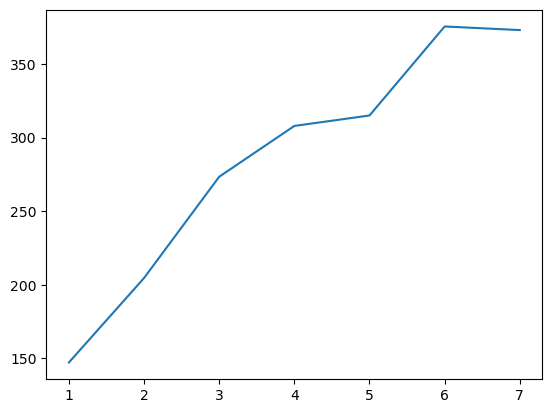

In [213]:
plt.plot([1,2,3,4,5,6,7],[controlT1,controlT2,controlT3,controlT4,controlT5, controlT6, controlT7])

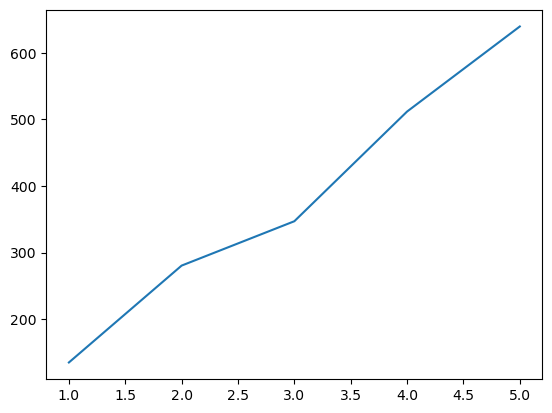

In [106]:
plt.plot([1,2,3,4,5],[t1,t2,t3,t4,t5])

In [125]:
k

NameError: name 'k' is not defined

In [56]:
def numSym(extB2, dim, startnum, endnum):
    costs = []
    for num in range(startnum, endnum+1):
        cost = costFromNum(extB2, dim, num)
        costs.extend([cost])
        
    return costs

In [57]:
symCosts = numSym(extB2, 10, 1, 6)

Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
 1           +4.1982543901307936e+03    4.50313354e+04    
 2           +3.8294192328823638e+03    3.97120570e+04    
 3           +3.2594568206168879e+03    1.73973295e+04    
 4           +3.1473114836096993e+03    1.21666204e+04    
 5           +3.0938735797600234e+03    1.67560996e+04    
 6           +2.9965178536792314e+03    8.88184159e+03    
 7           +2.9729451350819850e+03    1.98609933e+04    
 8           +2.8966057613575090e+03    1.24467895e+04    
 9           +2.8536136093413261e+03    1.11041726e+04    
10           +2.8517951682355442e+03    1.67526605e+04    
11           +2.8446755749201006e+03    1.60434634e+04    
12           +2.8187841376980427e+03    1.31570147e+04    
13           +2.7651986271166988e+03    5.61553158e+03    
14           +2.7583523495171830e+03    2.47272145e+04    
15           +2.7320289307819944e+03    2.

32           +2.5139393394215563e+03    3.34971887e+03    
33           +2.4676395807149534e+03    9.65337284e+03    
34           +2.4674701703974333e+03    1.14116940e+04    
35           +2.4667960908657424e+03    1.12917664e+04    
36           +2.4641573723952411e+03    1.08098813e+04    
37           +2.4545651086817247e+03    8.85208035e+03    
38           +2.4347781510473510e+03    3.01538432e+03    
39           +2.4094942870586442e+03    1.44734621e+04    
40           +2.3614935465582780e+03    2.96957472e+03    
41           +2.3541201839382525e+03    7.77335112e+03    
42           +2.3394914702013880e+03    2.74257485e+03    
43           +2.3278146821205660e+03    8.36548623e+03    
44           +2.3144840365135869e+03    5.18312402e+03    
45           +2.3119957541572880e+03    6.59948848e+03    
46           +2.3043495362535077e+03    3.74251505e+03    
47           +2.3003833526479825e+03    5.11589705e+03    
48           +2.2933583009624490e+03    3.13609232e+03  

12           +4.7209721909422669e+03    1.73885301e+04    
13           +4.6712024402684801e+03    1.43594600e+04    
14           +4.5647106992678619e+03    6.13453472e+03    
15           +4.4266995720070190e+03    2.27673670e+04    
16           +4.2189180104215093e+03    8.65215141e+03    
17           +4.1827242309501980e+03    7.41800108e+03    
18           +4.1500789562749578e+03    6.14166545e+03    
19           +4.1213969122358285e+03    6.98940607e+03    
20           +4.1187772729137878e+03    1.23685100e+04    
21           +4.1087103979568074e+03    1.14007765e+04    
22           +4.0755332132152639e+03    7.53613768e+03    
23           +4.0455980307209225e+03    5.43908419e+03    
24           +4.0219876377293012e+03    7.41690068e+03    
25           +4.0065544311145668e+03    9.23203373e+03    
26           +3.9698511050167108e+03    3.86008051e+03    
27           +3.8330341356123990e+03    3.65652164e+03    
28           +3.8008500608970166e+03    9.18051052e+03  

In [58]:
symCosts

[2123.4039235136242,
 2818.733752861415,
 2278.1635037381966,
 3705.087677578582,
 3499.8787734775465,
 3444.5032186693466]

In [59]:
symCosts2 = numSym(extB2, 10, 1, 6)

Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
 1           +4.2587256272260274e+03    5.37503349e+04    
 2           +3.2027108284987744e+03    3.54544982e+04    
 3           +2.8374828793531515e+03    1.89558083e+04    
 4           +2.7534052477622222e+03    1.84417618e+04    
 5           +2.6820414237011560e+03    1.80638249e+04    
 6           +2.6032820806252880e+03    1.51297884e+04    
 7           +2.5309721547269060e+03    9.51659871e+03    
 8           +2.4896285199745325e+03    1.63031293e+04    
 9           +2.4178784865509369e+03    8.63061868e+03    
10           +2.4113641244750320e+03    1.96850590e+04    
11           +2.3870050746705529e+03    1.71256311e+04    
12           +2.3216318973678262e+03    7.03910149e+03    
13           +2.2901676807712797e+03    1.00515118e+04    
14           +2.2605838741751400e+03    6.72965457e+03    
15           +2.2385660882571674e+03    1.

32           +3.0978039594208699e+03    5.96427821e+03    
33           +3.0881448546966694e+03    6.76893260e+03    
34           +3.0721319837806868e+03    4.30074313e+03    
35           +3.0637810239918949e+03    6.88748218e+03    
36           +3.0472759492139794e+03    3.40956121e+03    
37           +3.0331115074683185e+03    7.15218051e+03    
38           +3.0237771139338088e+03    7.12783307e+03    
39           +3.0072367007978305e+03    3.56742886e+03    
40           +3.0030416677306625e+03    8.49014030e+03    
41           +2.9894162793893634e+03    5.40312513e+03    
42           +2.9794259719177903e+03    4.27677859e+03    
43           +2.9713861136222490e+03    4.27337946e+03    
44           +2.9707539817291831e+03    7.88205182e+03    
45           +2.9683085767381008e+03    7.36595258e+03    
46           +2.9599316803315428e+03    5.31017687e+03    
47           +2.9541577671293589e+03    6.09753328e+03    
48           +2.9418968261808805e+03    2.72689778e+03  

12           +4.5610266767554485e+03    7.11532795e+03    
13           +4.5207465047029127e+03    7.42069870e+03    
14           +4.4815367159711723e+03    6.43971528e+03    
15           +4.4452558532682733e+03    7.35931324e+03    
16           +4.4092880700088126e+03    5.87199341e+03    
17           +4.3758594723021351e+03    7.41428424e+03    
18           +4.3752725916826985e+03    1.28849871e+04    
19           +4.3729430122138065e+03    1.26881721e+04    
20           +4.3639160512298722e+03    1.18973440e+04    
21           +4.3327555818309711e+03    8.71515954e+03    
22           +4.3073271928068789e+03    9.18007839e+03    
23           +4.2678677928325196e+03    5.98950475e+03    
24           +4.2494937007437475e+03    8.93330980e+03    
25           +4.2110086348424720e+03    4.18353891e+03    
26           +4.1779937438843890e+03    1.59985608e+04    
27           +4.0875044589297081e+03    6.24000236e+03    
28           +4.0667172867225918e+03    4.47209731e+03  

In [60]:
symCosts3 = numSym(extB2, 10, 1, 6)

Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
 1           +2.3527462482656756e+03    3.30606613e+04    
 2           +2.2922739063161653e+03    3.90270300e+04    
 3           +2.0828682598547989e+03    2.83463144e+04    
 4           +1.8903202126290439e+03    1.62674470e+04    
 5           +1.8559133720309449e+03    3.51656213e+04    
 6           +1.7351234731779102e+03    2.64600768e+04    
 7           +1.6954649730570516e+03    3.06946620e+04    
 8           +1.5710784094886642e+03    1.77046107e+04    
 9           +1.5527960516810258e+03    2.72024505e+04    
10           +1.4896669046388536e+03    1.98408605e+04    
11           +1.4675229599689462e+03    2.54620072e+04    
12           +1.3971491429971645e+03    1.53459339e+04    
13           +1.3639569116227115e+03    1.89578266e+04    
14           +1.3085321784233863e+03    1.20464712e+04    
15           +1.2870434440513548e+03    2.

32           +2.8580965244893405e+03    6.78446761e+03    
33           +2.8431848193911951e+03    3.46704213e+03    
34           +2.8324660603800908e+03    7.33535279e+03    
35           +2.8174124972839131e+03    4.64308358e+03    
36           +2.8124715232621729e+03    6.84864817e+03    
37           +2.7993862745221791e+03    3.05683217e+03    
38           +2.7878922977398342e+03    1.16282450e+04    
39           +2.7562484354533894e+03    4.67438757e+03    
40           +2.7550112929557999e+03    7.62830601e+03    
41           +2.7504259316969328e+03    6.52104977e+03    
42           +2.7386182417088389e+03    2.79335452e+03    
43           +2.7193039086417143e+03    9.86603548e+03    
44           +2.6995607996761200e+03    6.24840190e+03    
45           +2.6939093813446711e+03    6.50130564e+03    
46           +2.6817176952684540e+03    2.56142798e+03    
47           +2.6488957975968096e+03    7.69689719e+03    
48           +2.6329797004310262e+03    2.61506632e+03  

12           +4.3635439152975569e+03    1.20126581e+04    
13           +4.2722782833492329e+03    9.34238121e+03    
14           +4.1948212899118225e+03    1.22788131e+04    
15           +4.1789517884015077e+03    1.83941826e+04    
16           +4.1219867570056003e+03    1.46631220e+04    
17           +4.0240790544403771e+03    8.30682706e+03    
18           +3.9977010300881584e+03    1.67500812e+04    
19           +3.9153610450226379e+03    9.71456641e+03    
20           +3.8818765617471468e+03    1.25882830e+04    
21           +3.8120066587958054e+03    5.90214996e+03    
22           +3.7808790561239584e+03    2.35654969e+04    
23           +3.6743682901883226e+03    1.67123026e+04    
24           +3.5723147991706060e+03    5.02080191e+03    
25           +3.5359910642043819e+03    1.23901376e+04    
26           +3.4849124127930154e+03    6.85489654e+03    
27           +3.4618161149350408e+03    5.61316439e+03    
28           +3.4415730051431024e+03    6.48315264e+03  

In [61]:
symCosts4 = numSym(extB2, 10, 1, 6)

Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
 1           +3.5974242146748848e+03    3.04366216e+04    
 2           +3.2102392217581082e+03    3.62102425e+04    
 3           +3.1467508520647816e+03    3.67105245e+04    
 4           +2.9254958166614897e+03    2.69753319e+04    
 5           +2.7129977218574791e+03    7.64091350e+03    
 6           +2.6602611113422354e+03    1.20431930e+04    
 7           +2.6140796167820376e+03    7.87052010e+03    
 8           +2.5875671611041230e+03    1.24711419e+04    
 9           +2.5432396639381145e+03    7.34212337e+03    
10           +2.5297817706864662e+03    1.37102551e+04    
11           +2.4901794921431242e+03    7.00319392e+03    
12           +2.4827246661886970e+03    1.34435289e+04    
13           +2.4575746305464399e+03    9.34104297e+03    
14           +2.4553315667714764e+03    1.34544357e+04    
15           +2.4467883839509145e+03    1.

32           +2.2761239769764720e+03    3.16527525e+03    
33           +2.2262405496905999e+03    8.97858351e+03    
34           +2.2103797084083121e+03    5.28532563e+03    
35           +2.2102945755527699e+03    8.52078519e+03    
36           +2.2099557793907620e+03    8.43399699e+03    
37           +2.2086285986217831e+03    8.08629202e+03    
38           +2.2037837649161556e+03    6.69243178e+03    
39           +2.1929468107698349e+03    2.84716998e+03    
40           +2.1578429089656561e+03    6.18788181e+03    
41           +2.1559452971286532e+03    7.84491787e+03    
42           +2.1493972055286645e+03    5.73990202e+03    
43           +2.1440604039352306e+03    5.84063800e+03    
44           +2.1362839225080520e+03    4.07167676e+03    
45           +2.1316770027439225e+03    5.08546545e+03    
46           +2.1256844903865126e+03    4.45314278e+03    
47           +2.1198664732776501e+03    3.27204083e+03    
48           +2.1144269588385387e+03    4.44438512e+03  

12           +3.3835677104985161e+03    1.78196831e+04    
13           +3.2671164966075125e+03    8.06057313e+03    
14           +3.2316459806075432e+03    2.19029924e+04    
15           +3.1206333248323240e+03    1.25588008e+04    
16           +3.1057658383893222e+03    1.71137763e+04    
17           +3.0552344901916163e+03    1.20930003e+04    
18           +3.0417297991511168e+03    1.65346126e+04    
19           +2.9957963102084159e+03    1.17052794e+04    
20           +2.9817935754153764e+03    1.57698352e+04    
21           +2.9355452069287462e+03    1.04551747e+04    
22           +2.8946362045850078e+03    7.58118023e+03    
23           +2.8639733090604977e+03    1.02725686e+04    
24           +2.8404336824054994e+03    1.19465821e+04    
25           +2.7943670112526111e+03    5.98502320e+03    
26           +2.7607018242923400e+03    1.29386498e+04    
27           +2.7179955145156832e+03    8.67707801e+03    
28           +2.7002722164767224e+03    1.04168971e+04  

In [62]:
symCosts5 = numSym(extB2, 10, 1, 6)

Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
 1           +2.6986599207881081e+03    3.79240793e+04    
 2           +2.4500750293322812e+03    2.84542926e+04    
 3           +2.2590704095591377e+03    1.38010602e+04    
 4           +2.2149570666723521e+03    1.77941342e+04    
 5           +2.1341365025339160e+03    1.01490677e+04    
 6           +2.0973449685309402e+03    2.03314307e+04    
 7           +2.0077243143862383e+03    7.68139793e+03    
 8           +1.8088214596458326e+03    2.52926979e+04    
 9           +1.7667783345393796e+03    2.28634407e+04    
10           +1.6752259028621863e+03    5.66233971e+03    
11           +1.3980315980940795e+03    6.03270360e+03    
12           +1.3913474040695271e+03    5.47788128e+03    
13           +1.3849921508867840e+03    4.68564636e+03    
14           +1.3790658036708232e+03    5.31967888e+03    
15           +1.3790255063167358e+03    1.

32           +1.7919998602449632e+03    1.66970638e+04    
33           +1.7892635040945347e+03    1.62696976e+04    
34           +1.7789024140075869e+03    1.45417985e+04    
35           +1.7479142688956510e+03    7.77160465e+03    
36           +1.7355320064148168e+03    1.32514525e+04    
37           +1.7041940028080055e+03    5.54761917e+03    
38           +1.6381145564851156e+03    1.79556051e+04    
39           +1.5894686973146197e+03    8.12067128e+03    
40           +1.5813498833727822e+03    1.11674141e+04    
41           +1.5608153776081447e+03    4.80918199e+03    
42           +1.5058397514331955e+03    1.29091093e+04    
43           +1.4799485594735042e+03    4.96557938e+03    
44           +1.4781428582468336e+03    1.70266818e+04    
45           +1.4712178537977511e+03    1.56235032e+04    
46           +1.4487937577263756e+03    9.76914968e+03    
47           +1.4366560909697419e+03    8.02638967e+03    
48           +1.4252509494651524e+03    5.07316236e+03  

12           +3.6765999460190533e+03    2.04406190e+04    
13           +3.6754181901783504e+03    2.03676394e+04    
14           +3.6707251449970290e+03    2.00748460e+04    
15           +3.6525072420299462e+03    1.88900620e+04    
16           +3.5892217114140499e+03    1.39748483e+04    
17           +3.5438155551594323e+03    1.37499379e+04    
18           +3.4739135017492495e+03    8.31388533e+03    
19           +3.4579197363868934e+03    1.44986292e+04    
20           +3.4069373688999999e+03    8.88585576e+03    
21           +3.3730797707497190e+03    9.28175279e+03    
22           +3.3569906948775433e+03    1.29580804e+04    
23           +3.3094368325276605e+03    6.78083269e+03    
24           +3.2891811535007455e+03    1.20684832e+04    
25           +3.2394513632129260e+03    4.85439940e+03    
26           +3.1023824713593658e+03    1.24528429e+04    
27           +3.0610473747646506e+03    7.74298093e+03    
28           +3.0540223528173842e+03    1.04889133e+04  

In [63]:
SymCosts = symCosts
for i in range(2,6):
    SymCosts = np.add(SymCosts, eval("symCosts" + str(i)))
    
SymCosts = SymCosts/5

In [64]:
SymCosts

array([1588.28266654, 1725.34142466, 2255.5519955 , 3332.334206  ,
       4165.64319277, 3070.65117647])

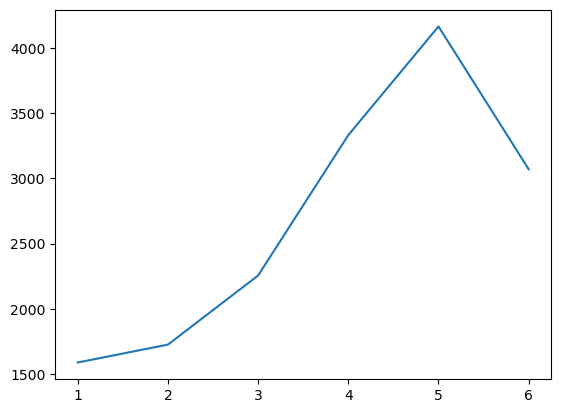

In [65]:
plt.plot([i for i in range(1,7)],SymCosts)

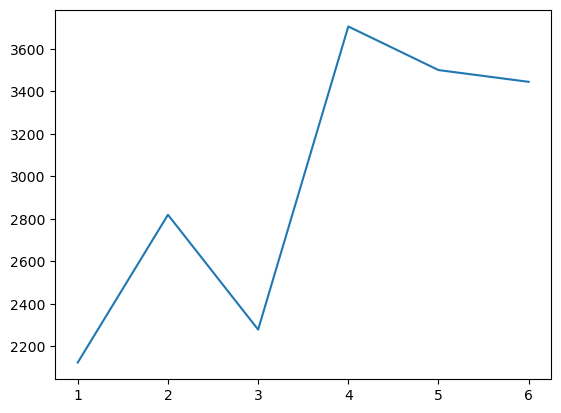

In [66]:
plt.plot([i for i in range(1,7)],symCosts)

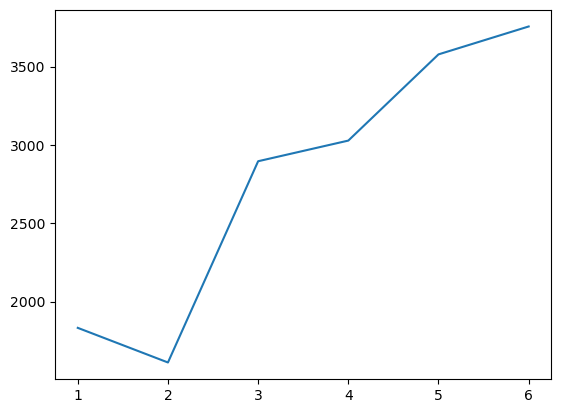

In [67]:
plt.plot([i for i in range(1,7)],symCosts2)

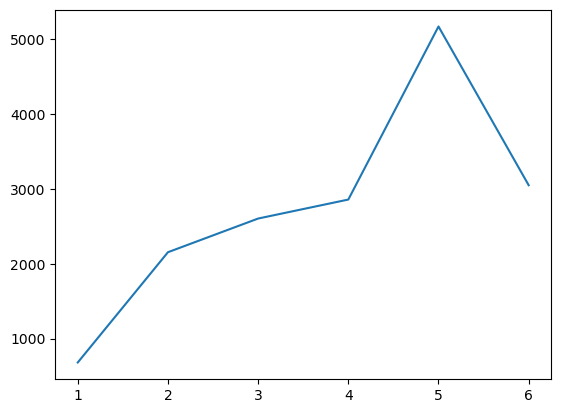

In [68]:
plt.plot([i for i in range(1,7)],symCosts3)

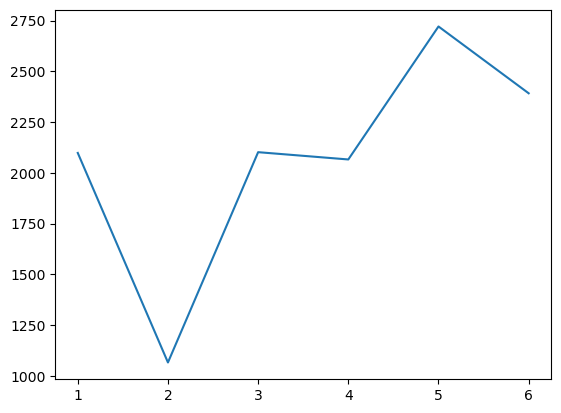

In [69]:
plt.plot([i for i in range(1,7)],symCosts4)

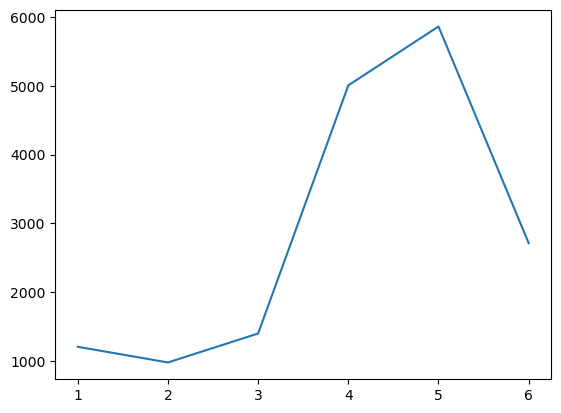

In [70]:
plt.plot([i for i in range(1,7)],symCosts5)

In [35]:
'''@pymanopt.function.autograd(ProdManifold)
def myCost(mat1, mat2): #mat2 is more like a vector, even in general.
    dim = mat2.shape[0]//mat1.shape[1]
    numfeats = mat1.shape[0]+dim
    #First, get a rearranged matrix V so we can multiply it with the A matrix (extB)
    place = 0
    bigV = []
    Mat1 = mat1.transpose()
    for i in range(Mat1.shape[0]):
        a = Mat1[i].reshape(((numfeats-dim)//dim,dim)).transpose()
        smallV = []
        for u in a:
            thing = np.insert(u,0,mat2[place])
            smallV.extend([thing])
            place += 1
        
        smallV = np.array(smallV)
        smallV = smallV.reshape(smallV.shape[0]*smallV.shape[1])
        bigV.extend([smallV])
    bigV = np.array(bigV)
    # Now we need to multiply it (the transpose) with extB
    term1 = extB2 @ bigV.transpose()
    term2 = anp.mean(term1, axis=0) # mean for each column
    term3 = anp.linalg.norm(term2) # should be close-ish to zero in the end.
    return term3'''

In [ ]:
# Well this doesn't work (too much RAM):

'''problem = pymanopt.Problem(ProdManifold, myCost)

optimizer = pymanopt.optimizers.SteepestDescent()
result = optimizer.run(problem)'''

Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    


In [115]:
import scipy.optimize

In [110]:
def normcond(w, numfeats=66, dim=10):
    # the length of 2 should be numfeats*dim
    t1 = [i for i in range(numfeats*dim)]
    t2 = [i*numfeats for i in range(dim)]
    for x in t2:
        t1.remove(x)
        
    
    term = sum([w[j]**2 for j in t1])
    return term

In [ ]:
def normcond2(W, numfeats, dim):
    asdf

In [132]:
# Here's (Ax)^T(Ax).
def myFunc(v):
    term1 = extB2 @ v
    term2 = np.mean(term1, axis=0)
    term3 = np.linalg.norm(term2)
    print(term1.reshape(term1.shape[0],))
    return term3

In [133]:
testV = np.random.rand(660,1)

In [134]:
testOut = myFunc(testV)

[ -24.23680479  -58.5261297    24.06808397 ...   51.89441051   96.19279694
 -119.58734149]


In [135]:
testOut

18.48888928169544

In [145]:
# Optimize.
def Optimize():
    #NormCond = scipy.optimize.NonlinearConstraint(normcond, 1, 1)
    initguess = np.random.rand(660,1).reshape(660,) #[1/np.sqrt(3),1/np.sqrt(3),1/np.sqrt(3),1,1,1]
    #sol = scipy.optimize.minimize(myFunc, initguess, constraints=[NormCond])
    sol = scipy.optimize.minimize(myFunc, initguess, options={'maxiter': 1})
    return sol

In [146]:
Optimize()

[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160428 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.9791

[-200.97913356  -81.52728125   96.75160429 ...   63.69582841  109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.69582841  109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.69582841  109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.9791

[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.69582837  109.37298788
 -146.15192796]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.69582839  109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.979

[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.9791

[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.97913355  -81.52728124   96.75160429 ...   63.6958284   109.3729879
 -146.15192797]
[-200.9791

...

[-109.07053602  -95.62667104  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]
[-109.07053603  -95.62667105  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]
[-109.07053602  -95.62667104  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]
[-109.07053602  -95.62667104  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]
[-109.07053603  -95.62667105  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]
[-109.07053601  -95.62667103  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]
[-109.07053602  -95.62667104  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]
[-109.07053602  -95.62667104  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]
[-109.07053602  -95.62667104  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]
[-109.07053602  -95.62667104  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]
[-109.07053602  -95.62667104  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]

[-109.07053602  -95.62667104  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]
[-109.07053602  -95.62667104  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]
[-109.07053602  -95.62667104  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]
[-109.07053602  -95.62667104  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]
[-109.07053602  -95.62667104  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]
[-109.07053603  -95.62667105  126.55236062 ...   58.38500652  108.87208032
 -136.20289833]
[-109.07053602  -95.62667103  126.55236061 ...   58.38500654  108.87208033
 -136.20289834]
[-109.07053602  -95.62667104  126.55236062 ...   58.38500652  108.87208032
 -136.20289833]
[-109.07053602  -95.62667104  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]
[-109.07053602  -95.62667104  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]
[-109.07053602  -95.62667104  126.55236062 ...   58.38500654  108.87208033
 -136.20289834]

[-109.07053602  -95.62667104  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]
[-109.07053602  -95.62667104  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]
[-109.07053602  -95.62667104  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]
[-109.07053602  -95.62667104  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]
[-109.07053602  -95.62667104  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]
[-109.07053602  -95.62667104  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]
[-109.07053602  -95.62667104  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]
[-109.07053602  -95.62667104  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]
[-109.07053602  -95.62667104  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]
[-109.07053602  -95.62667104  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]
[-109.07053602  -95.62667104  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]

[-109.07053602  -95.62667104  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]
[-109.07053602  -95.62667104  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]
[-109.07053602  -95.62667104  126.55236062 ...   58.38500655  108.87208034
 -136.20289834]


KeyboardInterrupt: 

In [ ]:
normcond

In [77]:
t1 = [i for i in range(660)]
t1

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,


In [78]:
t2 = [i*66 for i in range(10)]
t2

[0, 66, 132, 198, 264, 330, 396, 462, 528, 594]

In [73]:
t1

[0, 1, 2, 3, 4, 5, 6, 7, 8]

In [74]:
t3 = [t1.remove(x) for x in t2]

In [75]:
t3

[None, None, None]

In [76]:
t1

[0, 1, 2, 3, 6, 8]

In [161]:
TESTJ[0].shape

(6, 10)

In [203]:
id(B2)

140399535811920

In [172]:
id(B)

140406252594448

In [183]:
np.zeros((10-1)*(66)).shape

(594,)

In [204]:
B2.shape

(65536, 66)

In [187]:
B2 = np.resize(B2, (B2.shape[0],B2.shape[1],10))

In [188]:
B2.shape

(65536, 66, 10)

In [190]:
B2[0].shape

(66, 10)

In [191]:
B2[0][0]

array([ 1.00000000e+00,  1.16720831e+00, -2.32190007e+00, -1.63141299e-03,
       -8.17770459e-01, -4.59168102e+00,  9.61343906e+00,  4.00000000e+00,
        0.00000000e+00, -2.73949332e-01])

In [192]:
B2[0][1]

array([ 1.00000000e+00,  1.36237524e+00, -2.71014107e+00, -1.90419881e-03,
       -9.54508478e-01, -5.35944825e+00,  1.12208860e+01,  4.66883325e+00,
        0.00000000e+00, -3.19755938e-01])

In [193]:
testA = np.array([[1,2],[3,4]])

In [197]:
testA = np.resize(testA,(5,2,2))

In [198]:
testA.shape

(5, 2, 2)

In [199]:
testA[0]

array([[1, 2],
       [3, 4]])

In [201]:
testA[1]

array([[1, 2],
       [3, 4]])

In [180]:
B2[0] = np.append(B2[0],np.zeros((10-1)*(66)))

ValueError: could not broadcast input array from shape (660,) into shape (66,)

In [182]:
B2[0].shape

(66,)

In [175]:
B2.shape

(65536, 66)

In [168]:
newBthing

array([None], dtype=object)

In [164]:
np.zeros(5)

array([0., 0., 0., 0., 0.])

In [157]:
crapshot = np.tensordot(TESTJ, B, axes=((0,0)))

In [158]:
crapshot.shape

(6, 10, 66)

In [137]:
B.shape

(65536, 66)

In [ ]:
def tryNum(d):

    manifold = pymanopt.manifolds.stiefel.Stiefel(B.shape[1],d)
    # This cost function is the magnitude of B.mat
    @pymanopt.function.autograd(manifold)
    def myCost(mat):
        n = X.shape[0]
        #mat = u @ anp.diag(s) @ vt
        term1 = B @ mat
        term2 = 1/n*anp.linalg.norm(term1)
        return term2

    problem = pymanopt.Problem(manifold, myCost)

    optimizer = pymanopt.optimizers.SteepestDescent()
    result = optimizer.run(problem)
    
    return result

In [26]:
from jax import jacfwd, jacrev

In [27]:
J = jacfwd(Myf.f)(X)

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory allocating 1717986918400 bytes.

In [80]:
Myf.jacf(X)(anp.array([0,1,2,3,4,5,6,7,8,9]))

TypeError: 'numpy.ndarray' object is not callable

In [61]:
Myf.f(X).shape

(65536, 6)

In [ ]:
# Here, we're just vectorizing the previous function.
class invF():
    def __init__(self,f,X):
        self.ds = X
        self.invf = f.f
        
        
    def F(self,X):
        term = np.array([self.invf(x) for x in X])
        return term

    
    def getfunc(self):
        return self.F
    
    
    def getsmallfunc(self):
        return self.invf

In [ ]:
MYf4a = invf(myanswer.transpose()[0],X4)
MYf4b = invf(myanswer.transpose()[1],X4)
MYF4a = invF(MYf4a,X4) # Vectorize the function a.
MYF4b = invF(MYf4b,X4) # Vectorize the function b.
MYF4a.F(X4) # Test to make sure that we really get (about) 0 everywhere.

In [120]:
# No need to transform the data first.

def getCopiedFeatureMatrix(X, featureFit):
    B = poly.fit_transform(X)
    Bt = B.transpose()
    dim = featureFit.n_features_in_
    feats = featureFit.n_output_features_
    endarray = []
    for i in range(dim):
        print("Before " + str(i))
        print([i*Bt.shape[0], Bt.shape[1]])
        before = np.zeros([i*Bt.shape[0],Bt.shape[1]])
        print("After " + str(i))
        print([(dim-1-i)*Bt.shape[0], Bt.shape[1]])
        after = np.zeros([(dim-1-i)*Bt.shape[0],Bt.shape[1]])
        layer = np.vstack([before,Bt,after])
        endarray.extend(layer)
        
    endarray = np.array(endarray)
    return endarray

In [121]:
B.transpose().shape

(66, 65536)

In [ ]:
testthing = getCopiedFeatureMatrix(X,poly)

Before 0
[0, 65536]
After 0
[594, 65536]
Before 1
[66, 65536]
After 1
[528, 65536]
Before 2
[132, 65536]
After 2
[462, 65536]
Before 3
[198, 65536]
After 3
[396, 65536]
Before 4
[264, 65536]
After 4
[330, 65536]
Before 5
[330, 65536]
After 5
[264, 65536]
Before 6
[396, 65536]
After 6
[198, 65536]
Before 7
[462, 65536]
After 7
[132, 65536]
Before 8
[528, 65536]
After 8
[66, 65536]
Before 9
[594, 65536]
After 9
[0, 65536]


In [104]:
B.transpose()

array([[ 1.        ,  1.        ,  1.        , ...,  1.        ,
         1.        ,  1.        ],
       [ 1.16720831,  1.00600089, -2.27101507, ...,  1.18687087,
         0.18212683,  0.4809422 ],
       [-2.32190007, -2.61867836, -0.36240599, ..., -1.7674383 ,
        -2.45037386,  2.4537076 ],
       ...,
       [ 0.07504824, 10.93600337,  5.83826762, ...,  1.8482917 ,
         0.18092772,  0.29960745],
       [-0.27394933,  3.30696286,  2.41625074, ...,  1.35951892,
        -0.42535599,  0.5473641 ],
       [ 1.        ,  1.        ,  1.        , ...,  1.        ,
         1.        ,  1.        ]])

In [108]:
np.zeros([B.shape[0],B.shape[1]])

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [110]:
np.zeros([B.shape[1],B.shape[0]]).shape

(66, 65536)

In [ ]:
Btest = 

In [99]:
poly.n_features_in_

10

In [100]:
B.shape

(65536, 66)

In [101]:
poly.n_output_features_

66